In [3]:
# ============================================================
# COMPLETE MEMORY / CACHE / VARIABLE CLEANUP
# ============================================================

import os, gc, time, psutil
def get_user_variables():
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None: return {}
        excluded = {"In", "Out", "get_ipython", "exit", "quit"}
        return {name: value for name, value in ip.user_ns.items() if not name.startswith("_") and name not in excluded}
    except Exception:
        return {}
def get_ram_usage():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**2
def print_variable_information():
    variables = get_user_variables()
    print(f"Variable count  : {len(variables)}")
    if variables: print("Variables       : " + ", ".join(sorted(variables.keys())))
def clear_matplotlib_cache():
    try:
        import matplotlib.pyplot as plt
        print("\n[1] Closing Matplotlib figures...")
        plt.close("all")
        print("    Matplotlib figures closed.")
    except ImportError:
        print("\n[1] Matplotlib not installed.")
    except Exception as e:
        print(f"\n[1] Matplotlib warning: {e}")
def clear_tensorflow_memory():
    try:
        import tensorflow as tf
        print("\n[2] Clearing TensorFlow / Keras...")
        tf.keras.backend.clear_session()
        print("    Keras session cleared.")
        gpus = tf.config.list_physical_devices("GPU")
        if gpus:
            for i in range(len(gpus)):
                try:
                    info = tf.config.experimental.get_memory_info(f"GPU:{i}")
                    print(f"    GPU:{i} current: {info['current']/1024**2:.2f} MB")
                    print(f"    GPU:{i} peak   : {info['peak']/1024**2:.2f} MB")
                except Exception:
                    pass
                try: tf.config.experimental.reset_memory_stats(f"GPU:{i}")
                except Exception: pass
        print("    TensorFlow cleanup completed.")
    except ImportError:
        print("\n[2] TensorFlow not installed.")
    except Exception as e:
        print(f"\n[2] TensorFlow warning: {e}")
def force_garbage_collection(cycles=3):
    print("\n[3] Running garbage collection...")
    total = sum(gc.collect() for _ in range(cycles))
    print(f"    Garbage-collected objects: {total}")
def delete_model_variables():
    print("\n[4] Deleting user/model/data variables...")
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None:
            print("    Not running inside Jupyter.")
            return 0, []
        protected = {"os", "gc", "time", "psutil", "get_user_variables", "get_ram_usage", "print_variable_information", "clear_matplotlib_cache", "clear_tensorflow_memory", "force_garbage_collection", "delete_model_variables", "clear_cache_and_memory", "In", "Out", "get_ipython", "exit", "quit"}
        names = [name for name in list(ip.user_ns.keys()) if not name.startswith("_") and name not in protected]
        print(f"    Variables selected for deletion: {len(names)}")
        if names: print("    Deleting: " + ", ".join(sorted(names)))
        deleted = 0
        for name in names:
            try:
                del ip.user_ns[name]
                deleted += 1
            except Exception as e:
                print(f"    Could not delete {name}: {e}")
        print(f"    Successfully deleted: {deleted}")
        return deleted, names
    except Exception as e:
        print(f"    Variable cleanup warning: {e}")
        return 0, []
def clear_cache_and_memory():
    print("\n" + "=" * 70)
    print("COMPLETE MEMORY / CACHE / VARIABLE CLEANUP")
    print("=" * 70)
    before_ram = get_ram_usage()
    before_variables = get_user_variables()
    before_count = len(before_variables)
    print("\nBEFORE CLEANING")
    print("-" * 70)
    print(f"RAM usage       : {before_ram:.2f} MB")
    print(f"Variable count  : {before_count}")
    if before_variables: print("Variables       : " + ", ".join(sorted(before_variables.keys())))
    clear_matplotlib_cache()
    clear_tensorflow_memory()
    force_garbage_collection()
    deleted_count, deleted_names = delete_model_variables()
    print("\n[5] Final garbage collection...")
    total = sum(gc.collect() for _ in range(5))
    print(f"    Garbage-collected objects: {total}")
    time.sleep(1)
    after_ram = get_ram_usage()
    after_variables = get_user_variables()
    after_count = len(after_variables)
    print("\nAFTER CLEANING")
    print("-" * 70)
    print(f"RAM usage       : {after_ram:.2f} MB")
    print(f"Variable count  : {after_count}")
    if after_variables: print("Remaining       : " + ", ".join(sorted(after_variables.keys())))
    ram_difference = before_ram - after_ram
    print("\n" + "=" * 70)
    print("CLEANUP SUMMARY")
    print("=" * 70)
    print(f"Variables before : {before_count}")
    print(f"Variables after  : {after_count}")
    print(f"Variables deleted: {deleted_count}")
    print("-" * 70)
    print(f"RAM before       : {before_ram:.2f} MB")
    print(f"RAM after        : {after_ram:.2f} MB")
    if ram_difference >= 0: print(f"RAM released     : {ram_difference:.2f} MB")
    else: print(f"RAM difference   : +{abs(ram_difference):.2f} MB")
    print("=" * 70)
    print("CLEANUP COMPLETED")
    print("=" * 70)
clear_cache_and_memory()


COMPLETE MEMORY / CACHE / VARIABLE CLEANUP

BEFORE CLEANING
----------------------------------------------------------------------
RAM usage       : 2140.32 MB
Variable count  : 73
Variables       : A_test_raw, A_train_raw, A_val_raw, DROPOUT, EarlyStopping, GCNConv, GCN_EPOCHS, IMG_SIZE, Input, K_NEIGHBORS, LR_GCN, LinearSegmentedColormap, Model, ModelCheckpoint, NearestNeighbors, ReduceLROnPlateau, SEED, StandardScaler, X_test, X_train, X_val, all_idx, auc, build_knn_cosine_graph, c, class_names, class_to_idx, class_weights, classes, classification_report, clear_cache_and_memory, clear_matplotlib_cache, clear_tensorflow_memory, compute_class_weight, confusion_matrix, connected_components, data_dir, delete_model_variables, force_garbage_collection, gc, gcn_filter, get_ram_usage, get_user_variables, glob, idx_te, idx_tr, idx_tr_va, idx_va, label_binarize, labels_int, layers, load_raw_features, np, num_classes, os, p, paths, pd, plt, print_variable_information, psutil, random, regulari


***
<a name='import Packages'>
    
# 1 <span style='color:blue'>|</span> GCN_KNN_Cosine

Classes: ['Glioma', 'Meningioma', 'No_tumor', 'Pituitary']
Total: 7023

Dataset Split
Train: 4915
Val  : 1405
Test : 703

TRAIN
Glioma         : 1135 (23.09%)
Meningioma     : 1151 (23.42%)
No_tumor       : 1400 (28.48%)
Pituitary      : 1229 (25.01%)

VALIDATION
Glioma         :  324 (23.06%)
Meningioma     :  329 (23.42%)
No_tumor       :  400 (28.47%)
Pituitary      :  352 (25.05%)

TEST
Glioma         :  162 (23.04%)
Meningioma     :  165 (23.47%)
No_tumor       :  200 (28.45%)
Pituitary      :  176 (25.04%)

Class weights: {0: 1.0825991189427313, 1: 1.0675499565595135, 2: 0.8776785714285714, 3: 0.9997965825874695}

[STEP 1] Loading raw features
Raw dimension: 37632
Train: (4915, 37632)
Val  : (1405, 37632)
Test : (703, 37632)

[STEP 2] Building graphs
A_train: (4915, 4915)
A_val  : (1405, 1405)
A_test : (703, 703)
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Pa

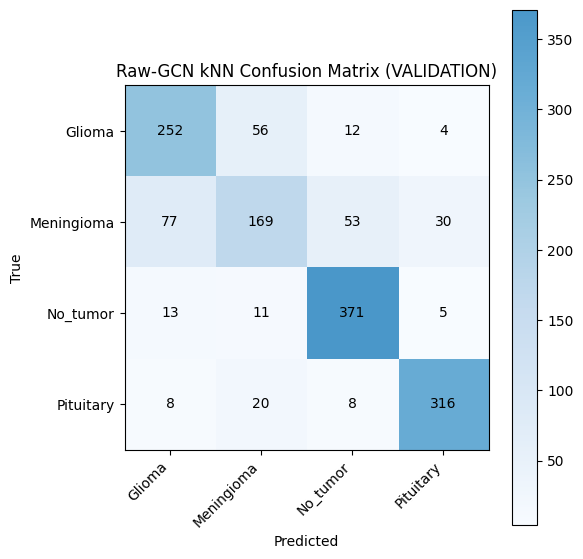

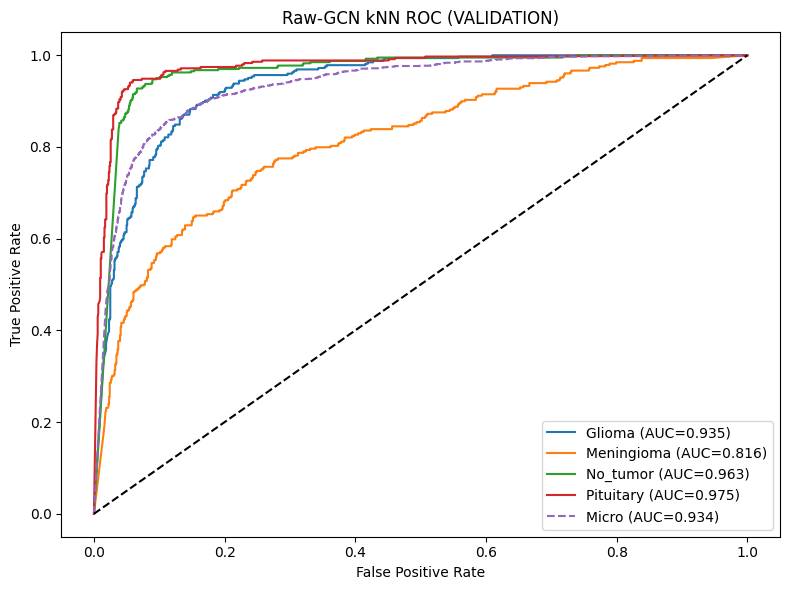


TEST
Loss     : 2.5174
Accuracy : 0.7653

Classification Report
              precision    recall  f1-score   support

      Glioma     0.6882    0.7901    0.7356       162
  Meningioma     0.6222    0.5091    0.5600       165
    No_tumor     0.8287    0.8950    0.8606       200
   Pituitary     0.8855    0.8352    0.8596       176

    accuracy                         0.7653       703
   macro avg     0.7562    0.7574    0.7540       703
weighted avg     0.7621    0.7653    0.7610       703

Confusion Matrix
[[128  21   5   8]
 [ 43  84  28  10]
 [  7  13 179   1]
 [  8  17   4 147]]

Class-wise errors
Class          FP      FN      Type I %    Type II %   
Glioma         58      34      10.72       20.99       
Meningioma     51      81      9.48        49.09       
No_tumor       37      21      7.36        10.50       
Pituitary      19      29      3.61        16.48       


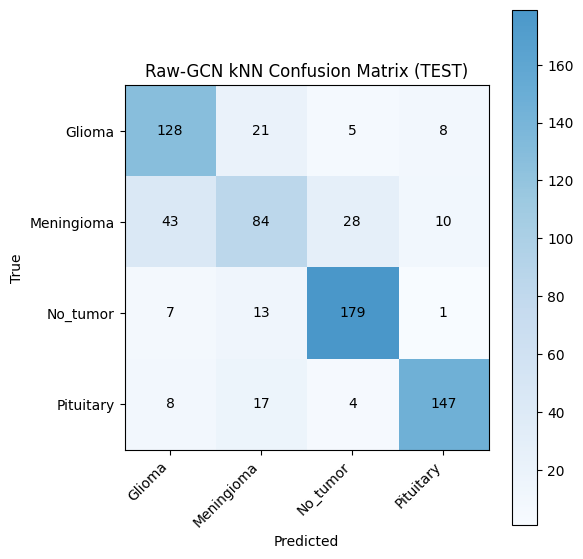

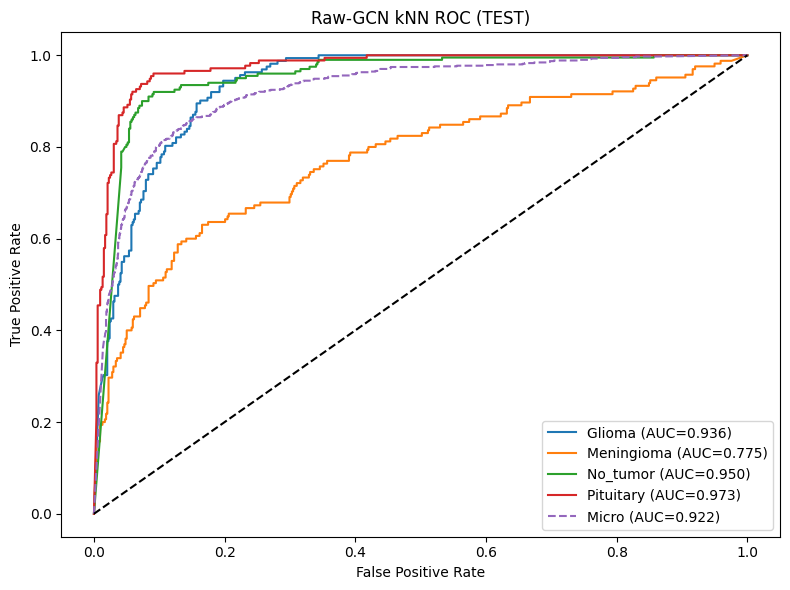

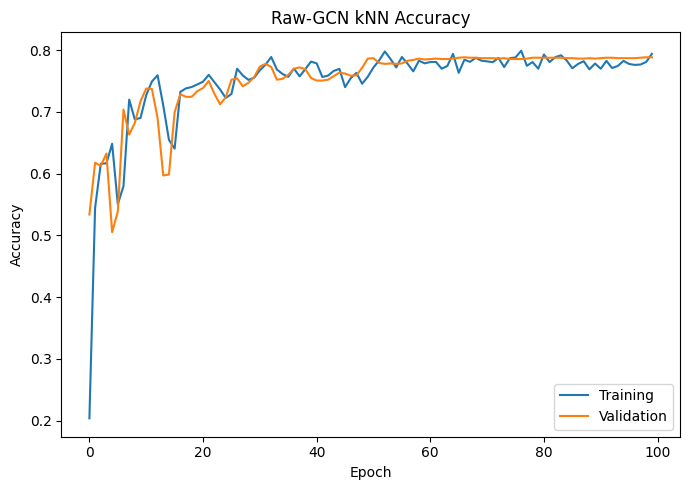

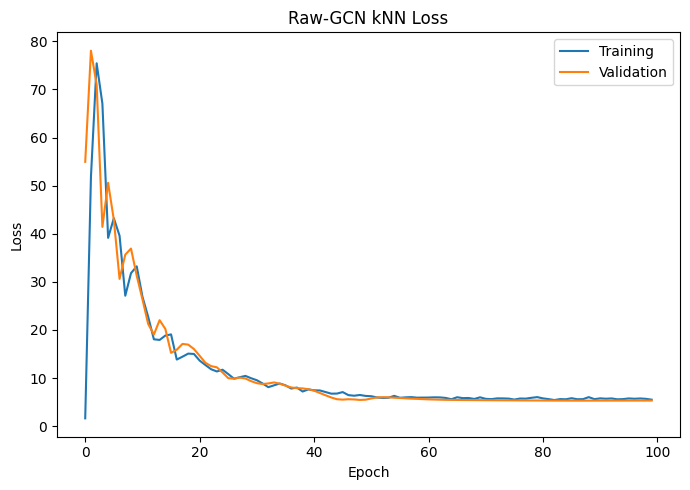


TRAIN GRAPH METRICS
 Nodes  FeatureDim  Edges    AvgDeg  MinDeg  MaxDeg  Density  Components  LargestCC
  4915       37632  44558 18.131434      12     277  0.00369           2       4900

EXPERIMENT 2 - RAW FEATURES + kNN COSINE + GCN
CNN                       : No
Raw image size            : (112, 112)
Raw feature dimension     : 37632
Standardization           : Train-fit StandardScaler
Graph                     : kNN
k                          : 12
Neighbour metric           : Cosine distance
Edge weight                : 1 - cosine distance
Symmetrization             : A = max(A, A.T)
Self-loops                 : Yes
GCN normalization          : gcn_filter
GCN hidden units           : 64
Dropout                    : 0.3
Learning rate              : 0.005
Label smoothing            : 0.05
Classes                    : 4
Seed                       : 123


In [5]:
import os,glob,random
import numpy as np
import pandas as pd
import scipy.sparse as sp
import tensorflow as tf
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap
from scipy.sparse.csgraph import connected_components
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,label_binarize
from sklearn.neighbors import NearestNeighbors
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report,confusion_matrix,roc_curve,auc
from tensorflow.keras import layers,Input,Model,regularizers
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from spektral.layers import GCNConv
from spektral.utils.convolution import gcn_filter


# ============================================================
# CONFIG
# ============================================================

SEED=123; K_NEIGHBORS=12; IMG_SIZE=(112,112); GCN_EPOCHS=100; LR_GCN=0.005; DROPOUT=0.3
data_dir=r"D:/Customised_CNN/dataset/Brain_Tumor/four_class"

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)


# ============================================================
# LOAD PATHS
# ============================================================

class_names=sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir,d))])
class_to_idx={c:i for i,c in enumerate(class_names)}

paths,labels_int=[],[]
for c in class_names:
    for p in glob.glob(os.path.join(data_dir,c,"*")):
        if p.lower().endswith((".jpg",".jpeg",".png",".bmp",".tif",".tiff")):
            paths.append(p); labels_int.append(class_to_idx[c])

paths=np.asarray(paths); labels_int=np.asarray(labels_int,dtype=np.int32)
num_classes=len(class_names); all_idx=np.arange(len(paths))
print("Classes:",class_names); print("Total:",len(paths))


# ============================================================
# STRATIFIED 70 / 20 / 10
# ============================================================

idx_tr_va,idx_te=train_test_split(all_idx,test_size=0.10,random_state=SEED,stratify=labels_int)
idx_tr,idx_va=train_test_split(idx_tr_va,test_size=2/9,random_state=SEED,stratify=labels_int[idx_tr_va])

print("\nDataset Split"); print("Train:",len(idx_tr)); print("Val  :",len(idx_va)); print("Test :",len(idx_te))


# ============================================================
# DISTRIBUTION
# ============================================================

def show_distribution(name,idx):
    print(f"\n{name}")
    for i,c in enumerate(class_names):
        n=np.sum(labels_int[idx]==i); print(f"{c:<15}: {n:4d} ({100*n/len(idx):.2f}%)")

show_distribution("TRAIN",idx_tr); show_distribution("VALIDATION",idx_va); show_distribution("TEST",idx_te)


# ============================================================
# CLASS WEIGHTS - TRAIN ONLY
# ============================================================

classes=np.arange(num_classes)
weights=compute_class_weight(class_weight="balanced",classes=classes,y=labels_int[idx_tr])
class_weights={int(c):float(w) for c,w in zip(classes,weights)}
print("\nClass weights:",class_weights)


# ============================================================
# RAW FEATURES - NO CNN
# ============================================================

def load_raw_features(selected_paths):
    features=[]
    for p in selected_paths:
        img=tf.io.read_file(p); img=tf.image.decode_image(img,channels=3,expand_animations=False)
        img=tf.image.resize(img,IMG_SIZE); img=tf.cast(img,tf.float32)/255.0
        features.append(tf.reshape(img,[-1]).numpy())
    return np.asarray(features,dtype=np.float32)

print("\n[STEP 1] Loading raw features")
X_train=load_raw_features(paths[idx_tr]); X_val=load_raw_features(paths[idx_va]); X_test=load_raw_features(paths[idx_te])
print("Raw dimension:",X_train.shape[1])


# ============================================================
# STANDARDIZATION - TRAIN FIT ONLY
# ============================================================

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train).astype(np.float32)
X_val=scaler.transform(X_val).astype(np.float32)
X_test=scaler.transform(X_test).astype(np.float32)

print("Train:",X_train.shape); print("Val  :",X_val.shape); print("Test :",X_test.shape)


# ============================================================
# kNN COSINE GRAPH
# EXACT SAME RULE AS EXPERIMENT 1
# ============================================================

def build_knn_cosine_graph(X,k=K_NEIGHBORS):
    n=len(X); k=min(k,n-1)
    knn=NearestNeighbors(n_neighbors=k+1,metric="cosine").fit(X)
    dist,idx=knn.kneighbors(X); rows,cols,vals=[],[],[]

    for i in range(n):
        for j,d in zip(idx[i],dist[i]):
            if i!=j:
                w=1-float(d)
                if w>0: rows.append(i); cols.append(j); vals.append(w)

    A=sp.coo_matrix((vals,(rows,cols)),shape=(n,n),dtype=np.float32).tocsr()
    A=A.maximum(A.T); A.setdiag(1.0); A.eliminate_zeros()
    return A


# ============================================================
# SCIPY -> TF SPARSE
# ============================================================

def to_tf_sparse(A):
    A=A.tocoo()
    indices=np.column_stack((A.row,A.col)).astype(np.int64); values=A.data.astype(np.float32)
    A_tf=tf.SparseTensor(indices=indices,values=values,dense_shape=A.shape)
    return tf.sparse.reorder(A_tf)


# ============================================================
# BUILD + NORMALIZE GRAPHS
# ============================================================

print("\n[STEP 2] Building graphs")

A_train_raw=build_knn_cosine_graph(X_train); A_val_raw=build_knn_cosine_graph(X_val); A_test_raw=build_knn_cosine_graph(X_test)

assert A_train_raw is not None; assert A_val_raw is not None; assert A_test_raw is not None
assert sp.issparse(A_train_raw); assert sp.issparse(A_val_raw); assert sp.issparse(A_test_raw)

A_train_raw=A_train_raw.tocsr(); A_val_raw=A_val_raw.tocsr(); A_test_raw=A_test_raw.tocsr()

A_train=sp.csr_matrix(
    gcn_filter(A_train_raw.toarray()),
    dtype=np.float32
)

A_val=sp.csr_matrix(
    gcn_filter(A_val_raw.toarray()),
    dtype=np.float32
)

A_test=sp.csr_matrix(
    gcn_filter(A_test_raw.toarray()),
    dtype=np.float32
)

A_train.sort_indices(); A_val.sort_indices(); A_test.sort_indices()
A_train_tf=to_tf_sparse(A_train); A_val_tf=to_tf_sparse(A_val); A_test_tf=to_tf_sparse(A_test)

print("A_train:",A_train.shape); print("A_val  :",A_val.shape); print("A_test :",A_test.shape)


# ============================================================
# LABELS
# ============================================================

train_labels=labels_int[idx_tr]; val_labels=labels_int[idx_va]; test_labels=labels_int[idx_te]
y_train=to_categorical(train_labels,num_classes).astype(np.float32)
y_val=to_categorical(val_labels,num_classes).astype(np.float32)
y_test=to_categorical(test_labels,num_classes).astype(np.float32)


# ============================================================
# GCN
# ============================================================

def build_gcn(feature_dim):
    X_in=Input(shape=(feature_dim,),name="features")
    A_in=Input(shape=(None,),sparse=True,name="graph")
    
    
    x=GCNConv(64,activation="relu",kernel_regularizer=regularizers.l2(5e-4))([X_in,A_in])
    x=layers.Dropout(DROPOUT)(x); out=GCNConv(num_classes,activation="softmax")([x,A_in])
    model=Model([X_in,A_in],out)
    model.compile(optimizer=tf.keras.optimizers.Adam(LR_GCN),
                  loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
                  weighted_metrics=["accuracy"])
    return model

tf.keras.backend.clear_session()
gcn_model=build_gcn(X_train.shape[1]); gcn_model.summary()


# ============================================================
# CALLBACKS
# ============================================================

callbacks=[
    EarlyStopping(monitor="val_loss",patience=20,restore_best_weights=True),
    ModelCheckpoint("best_raw_knn_gcn.weights.h5",monitor="val_loss",save_best_only=True,save_weights_only=True),
    ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=3,min_lr=1e-5)
]


# ============================================================
# TRAIN - FULL GRAPH / FULL BATCH
# ============================================================

print("\n[STEP 3] Training")

history=gcn_model.fit([X_train,A_train_tf],y_train,batch_size=len(X_train),epochs=GCN_EPOCHS,
                      validation_data=([X_val,A_val_tf],y_val),validation_batch_size=len(X_val),
                      class_weight=class_weights,shuffle=False,callbacks=callbacks,verbose=1)


# ============================================================
# SEPARATE INFERENCE MODEL FOR VARIABLE GRAPH SIZE
# ============================================================



# ============================================================
# LIGHT CONFUSION MATRIX
# ============================================================

light_blues=LinearSegmentedColormap.from_list("light_blues",plt.cm.Blues(np.linspace(0,0.60,256)))


# ============================================================
# EVALUATION
# ============================================================

def evaluate_model(name,X,A_tf,y_true):
    y_cat=to_categorical(y_true,num_classes).astype(np.float32)
    prob=gcn_model([X,A_tf],training=False).numpy(); pred=np.argmax(prob,axis=1)

    cce=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)
    loss=float(cce(y_cat,prob).numpy()); acc=float(np.mean(pred==y_true))

    print("\n"+"="*65); print(name); print("="*65)
    print(f"Loss     : {loss:.4f}"); print(f"Accuracy : {acc:.4f}")
    print("\nClassification Report")
    print(classification_report(y_true,pred,target_names=class_names,digits=4,zero_division=0))

    cm=confusion_matrix(y_true,pred)
    print("Confusion Matrix"); print(cm)
    print("\nClass-wise errors")
    print(f"{'Class':<15}{'FP':<8}{'FN':<8}{'Type I %':<12}{'Type II %':<12}")

    for i,c in enumerate(class_names):
        TP=cm[i,i]; FN=cm[i,:].sum()-TP; FP=cm[:,i].sum()-TP; TN=cm.sum()-TP-FP-FN
        type1=FP/(FP+TN) if FP+TN else 0; type2=FN/(FN+TP) if FN+TP else 0
        print(f"{c:<15}{FP:<8}{FN:<8}{100*type1:<12.2f}{100*type2:<12.2f}")

    plt.figure(figsize=(6,6)); plt.imshow(cm,cmap=light_blues,interpolation="nearest"); plt.colorbar()
    plt.xticks(range(num_classes),class_names,rotation=45,ha="right"); plt.yticks(range(num_classes),class_names)
    for i in range(num_classes):
        for j in range(num_classes): plt.text(j,i,cm[i,j],ha="center",va="center",color="black")
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Raw-GCN kNN Confusion Matrix ({name})"); plt.tight_layout(); plt.show()

    y_bin=label_binarize(y_true,classes=np.arange(num_classes)); plt.figure(figsize=(8,6))
    for i in range(num_classes):
        fpr,tpr,_=roc_curve(y_bin[:,i],prob[:,i]); roc_auc=auc(fpr,tpr)
        plt.plot(fpr,tpr,label=f"{class_names[i]} (AUC={roc_auc:.3f})")

    fpr,tpr,_=roc_curve(y_bin.ravel(),prob.ravel()); micro_auc=auc(fpr,tpr)
    plt.plot(fpr,tpr,linestyle="--",label=f"Micro (AUC={micro_auc:.3f})"); plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title(f"Raw-GCN kNN ROC ({name})")
    plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

    return {"loss":loss,"accuracy":acc,"prob":prob,"pred":pred,"cm":cm}


# ============================================================
# VALIDATION + TEST
# ============================================================

val_results=evaluate_model("VALIDATION",X_val,A_val_tf,val_labels)
test_results=evaluate_model("TEST",X_test,A_test_tf,test_labels)


# ============================================================
# TRAINING CURVES
# ============================================================

plt.figure(figsize=(7,5))
plt.plot(history.history["accuracy"],label="Training"); plt.plot(history.history["val_accuracy"],label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Raw-GCN kNN Accuracy"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,5))
plt.plot(history.history["loss"],label="Training"); plt.plot(history.history["val_loss"],label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Raw-GCN kNN Loss"); plt.legend(); plt.tight_layout(); plt.show()


# ============================================================
# GRAPH METRICS
# ============================================================

def graph_metrics(A,X):
    A=A.copy().tocsr(); N=A.shape[0]; F=X.shape[1]
    A.setdiag(0); A.eliminate_zeros()
    edges=A.nnz//2; degree=np.asarray((A>0).sum(axis=1)).ravel()
    density=2*edges/(N*(N-1)) if N>1 else 0
    n_components,component_labels=connected_components(A,directed=False,return_labels=True)
    sizes=np.bincount(component_labels)
    return {"Nodes":N,"FeatureDim":F,"Edges":edges,"AvgDeg":degree.mean(),"MinDeg":degree.min(),
            "MaxDeg":degree.max(),"Density":density,"Components":n_components,"LargestCC":sizes.max()}

print("\nTRAIN GRAPH METRICS")
print(pd.DataFrame([graph_metrics(A_train_raw,X_train)]).to_string(index=False))


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n"+"="*70); print("EXPERIMENT 2 - RAW FEATURES + kNN COSINE + GCN"); print("="*70)
print("CNN                       : No")
print("Raw image size            :",IMG_SIZE)
print("Raw feature dimension     :",X_train.shape[1])
print("Standardization           : Train-fit StandardScaler")
print("Graph                     : kNN")
print("k                          :",K_NEIGHBORS)
print("Neighbour metric           : Cosine distance")
print("Edge weight                : 1 - cosine distance")
print("Symmetrization             : A = max(A, A.T)")
print("Self-loops                 : Yes")
print("GCN normalization          : gcn_filter")
print("GCN hidden units           : 64")
print("Dropout                    :",DROPOUT)
print("Learning rate              :",LR_GCN)
print("Label smoothing            : 0.05")
print("Classes                    :",num_classes)
print("Seed                       :",SEED)
print("="*70)

Classes: ['Glioma', 'Meningioma', 'No_tumor', 'Pituitary']
Total: 7023

Dataset Split
Train: 4915
Val  : 1405
Test : 703

TRAIN
Glioma         : 1135 (23.09%)
Meningioma     : 1151 (23.42%)
No_tumor       : 1400 (28.48%)
Pituitary      : 1229 (25.01%)

VALIDATION
Glioma         :  324 (23.06%)
Meningioma     :  329 (23.42%)
No_tumor       :  400 (28.47%)
Pituitary      :  352 (25.05%)

TEST
Glioma         :  162 (23.04%)
Meningioma     :  165 (23.47%)
No_tumor       :  200 (28.45%)
Pituitary      :  176 (25.04%)

[STEP 1] Loading raw features
Raw feature dimension: 37632
Train: (4915, 37632)
Val  : (1405, 37632)
Test : (703, 37632)

Nodes: 7023
Feature dimension: 37632

[STEP 2] Building kNN cosine graph
Adjacency shape: (7023, 7023)
Normalized adjacency: (7023, 7023)

GRAPH STATISTICS
Nodes             : 7023
Edges             : 61910
k                 : 12
Average degree    : 17.63
Minimum degree    : 12
Maximum degree    : 303
Density           : 0.002511
Components        : 4
Large

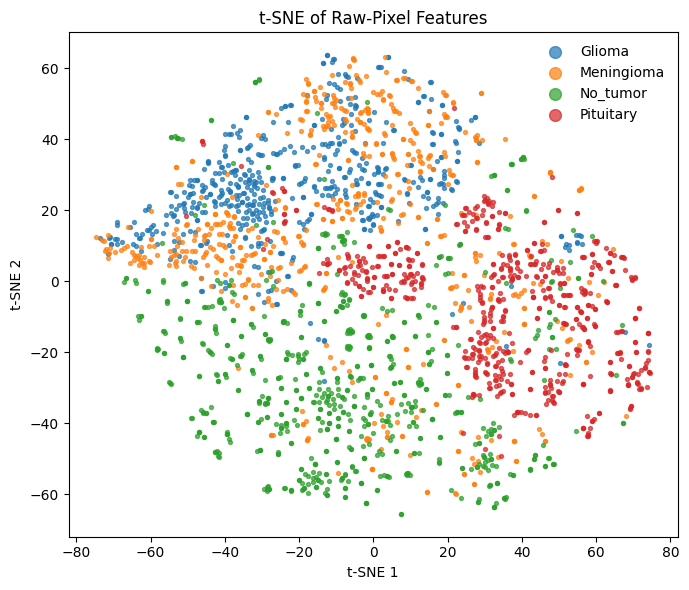

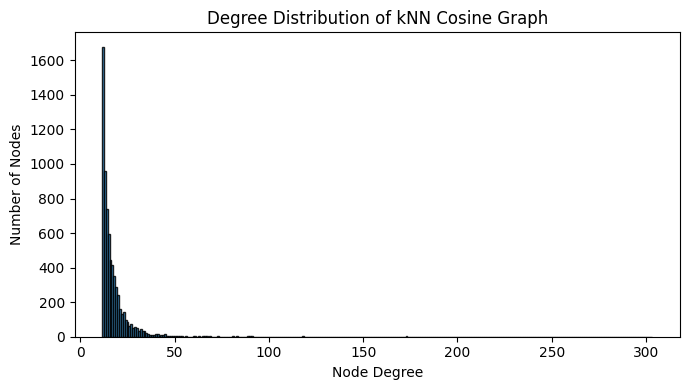

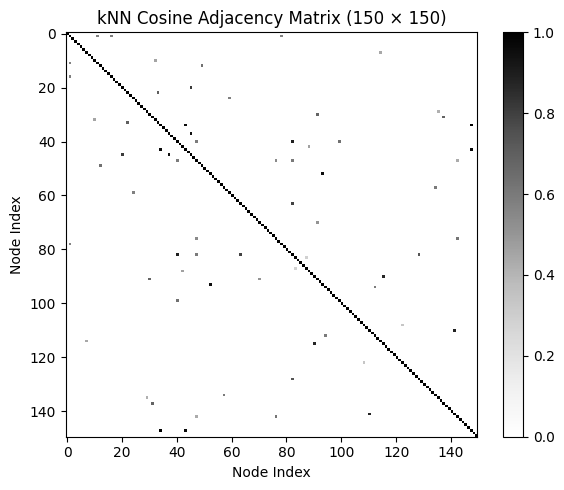


GCN ARCHITECTURE
Model: "Raw_kNN_GCN"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 features (InputLayer)          [(None, 37632)]      0           []                               
                                                                                                  
 graph (InputLayer)             [(None, None)]       0           []                               
                                                                                                  
 GCN_1 (GCNConv)                (None, 64)           2408512     ['features[0][0]',               
                                                                  'graph[0][0]']                  
                                                                                                  
 Dropout (Dropout)              (None, 64)           0           ['GCN

In [6]:
import os, glob, random
import numpy as np
import scipy.sparse as sp
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from scipy.sparse.csgraph import connected_components

from tensorflow.keras import layers, Input, Model, regularizers
from spektral.layers import GCNConv
from spektral.utils.convolution import gcn_filter


# ============================================================
# CONFIG
# ============================================================

SEED=123
K_NEIGHBORS=12
IMG_SIZE=(112,112)

HIDDEN=64
DROPOUT=0.3
WD=5e-4

TSNE_MAX_N=2500

data_dir=r"D:/Customised_CNN/dataset/Brain_Tumor/four_class"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# LOAD PATHS
# ============================================================

class_names=sorted([
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir,d))
])

class_to_idx={c:i for i,c in enumerate(class_names)}

paths=[]
labels_int=[]

for c in class_names:

    for p in glob.glob(os.path.join(data_dir,c,"*")):

        if p.lower().endswith(
            (".jpg",".jpeg",".png",".bmp",".tif",".tiff")
        ):

            paths.append(p)
            labels_int.append(class_to_idx[c])


paths=np.asarray(paths)

labels_int=np.asarray(
    labels_int,
    dtype=np.int32
)

num_classes=len(class_names)

all_idx=np.arange(len(paths))


print("Classes:",class_names)
print("Total:",len(paths))


# ============================================================
# STRATIFIED 70 / 20 / 10
# ============================================================

idx_tr_va,idx_te=train_test_split(
    all_idx,
    test_size=0.10,
    random_state=SEED,
    stratify=labels_int
)

idx_tr,idx_va=train_test_split(
    idx_tr_va,
    test_size=2/9,
    random_state=SEED,
    stratify=labels_int[idx_tr_va]
)


print("\nDataset Split")
print("Train:",len(idx_tr))
print("Val  :",len(idx_va))
print("Test :",len(idx_te))


# ============================================================
# CLASS DISTRIBUTION
# ============================================================

def show_distribution(name,idx):

    print(f"\n{name}")

    for i,c in enumerate(class_names):

        n=np.sum(
            labels_int[idx]==i
        )

        print(
            f"{c:<15}: "
            f"{n:4d} "
            f"({100*n/len(idx):.2f}%)"
        )


show_distribution(
    "TRAIN",
    idx_tr
)

show_distribution(
    "VALIDATION",
    idx_va
)

show_distribution(
    "TEST",
    idx_te
)


# ============================================================
# RAW PIXEL FEATURES
# ============================================================

def load_raw_features(selected_paths):

    features=[]

    for p in selected_paths:

        img=tf.io.read_file(p)

        img=tf.image.decode_image(
            img,
            channels=3,
            expand_animations=False
        )

        img=tf.image.resize(
            img,
            IMG_SIZE
        )

        img=tf.cast(
            img,
            tf.float32
        )/255.0

        features.append(
            tf.reshape(
                img,
                [-1]
            ).numpy()
        )

    return np.asarray(
        features,
        dtype=np.float32
    )


print("\n[STEP 1] Loading raw features")


X_train_raw=load_raw_features(
    paths[idx_tr]
)

X_val_raw=load_raw_features(
    paths[idx_va]
)

X_test_raw=load_raw_features(
    paths[idx_te]
)


print(
    "Raw feature dimension:",
    X_train_raw.shape[1]
)


# ============================================================
# STANDARDIZATION
# TRAIN FIT ONLY
# ============================================================

scaler=StandardScaler()

X_train=scaler.fit_transform(
    X_train_raw
).astype(np.float32)

X_val=scaler.transform(
    X_val_raw
).astype(np.float32)

X_test=scaler.transform(
    X_test_raw
).astype(np.float32)


print("Train:",X_train.shape)
print("Val  :",X_val.shape)
print("Test :",X_test.shape)


# ============================================================
# COMBINED FEATURES FOR VISUALISATION
# ============================================================

X_all=np.vstack([
    X_train,
    X_val,
    X_test
])

y_all=np.concatenate([
    labels_int[idx_tr],
    labels_int[idx_va],
    labels_int[idx_te]
])


N=X_all.shape[0]
F=X_all.shape[1]


print("\nNodes:",N)
print("Feature dimension:",F)


# ============================================================
# kNN COSINE GRAPH
# SAME RULE AS EXPERIMENT 2
# ============================================================

def build_knn_cosine_graph(
    X,
    k=K_NEIGHBORS
):

    n=len(X)

    k=min(
        k,
        n-1
    )

    knn=NearestNeighbors(
        n_neighbors=k+1,
        metric="cosine"
    ).fit(X)

    dist,idx=knn.kneighbors(
        X
    )

    rows=[]
    cols=[]
    vals=[]

    for i in range(n):

        for j,d in zip(
            idx[i],
            dist[i]
        ):

            if i!=j:

                w=1-float(d)

                if w>0:

                    rows.append(i)
                    cols.append(j)
                    vals.append(w)

    A=sp.coo_matrix(
        (
            vals,
            (
                rows,
                cols
            )
        ),
        shape=(n,n),
        dtype=np.float32
    ).tocsr()

    A=A.maximum(
        A.T
    )

    A.setdiag(
        1.0
    )

    A.eliminate_zeros()

    return A


# ============================================================
# BUILD GRAPH
# ============================================================

print(
    "\n[STEP 2] Building kNN cosine graph"
)


A_raw=build_knn_cosine_graph(
    X_all
)


print(
    "Adjacency shape:",
    A_raw.shape
)


# ============================================================
# NORMALIZED GRAPH
# ============================================================

A_norm=sp.csr_matrix(
    gcn_filter(
        A_raw.toarray()
    ),
    dtype=np.float32
)


print(
    "Normalized adjacency:",
    A_norm.shape
)


# ============================================================
# GRAPH STATISTICS
# ============================================================

A_no_self=A_raw.copy().tocsr()

A_no_self.setdiag(
    0
)

A_no_self.eliminate_zeros()


degree_counts=np.asarray(
    (A_no_self>0).sum(axis=1)
).ravel()


num_edges=A_no_self.nnz//2


avg_degree=degree_counts.mean()

min_degree=degree_counts.min()

max_degree=degree_counts.max()


density=(
    2*num_edges/
    (N*(N-1))
    if N>1
    else 0
)


n_components,component_labels=connected_components(
    A_no_self,
    directed=False,
    return_labels=True
)


component_sizes=np.bincount(
    component_labels
)


largest_cc=component_sizes.max()


print("\n"+"="*60)
print("GRAPH STATISTICS")
print("="*60)

print("Nodes             :",N)
print("Edges             :",num_edges)
print("k                 :",K_NEIGHBORS)
print("Average degree    :",f"{avg_degree:.2f}")
print("Minimum degree    :",min_degree)
print("Maximum degree    :",max_degree)
print("Density           :",f"{density:.6f}")
print("Components        :",n_components)
print("Largest component :",largest_cc)
print("Adjacency nnz     :",A_raw.nnz)

print("="*60)


# ============================================================
# t-SNE
# ============================================================

print(
    "\n[STEP 3] Running t-SNE"
)


if N>TSNE_MAX_N:

    rng=np.random.RandomState(
        SEED
    )

    selected=rng.choice(
        N,
        TSNE_MAX_N,
        replace=False
    )

    X_tsne=X_all[selected]

    y_tsne=y_all[selected]

else:

    X_tsne=X_all

    y_tsne=y_all


tsne=TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    perplexity=30,
    random_state=SEED
)


X_2d=tsne.fit_transform(
    X_tsne
)


plt.figure(
    figsize=(7,6)
)


for i,c in enumerate(class_names):

    mask=y_tsne==i

    plt.scatter(
        X_2d[mask,0],
        X_2d[mask,1],
        s=8,
        alpha=0.7,
        label=c
    )


plt.xlabel(
    "t-SNE 1"
)

plt.ylabel(
    "t-SNE 2"
)

plt.title(
    "t-SNE of Raw-Pixel Features"
)

plt.legend(
    markerscale=3,
    frameon=False
)

plt.tight_layout()

plt.show()


# ============================================================
# DEGREE DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(7,4)
)


bins=np.arange(
    degree_counts.min(),
    degree_counts.max()+2
)-0.5


plt.hist(
    degree_counts,
    bins=bins,
    edgecolor="black",
    alpha=0.85
)


plt.xlabel(
    "Node Degree"
)

plt.ylabel(
    "Number of Nodes"
)

plt.title(
    "Degree Distribution of kNN Cosine Graph"
)

plt.tight_layout()

plt.show()


# ============================================================
# ADJACENCY MATRIX SNAPSHOT
# ============================================================

subN=min(
    150,
    N
)


A_small=A_raw[
    :subN,
    :subN
].toarray()


plt.figure(
    figsize=(6,5)
)


plt.imshow(
    A_small,
    cmap="Greys",
    interpolation="nearest",
    aspect="auto"
)


plt.colorbar()

plt.xlabel(
    "Node Index"
)

plt.ylabel(
    "Node Index"
)

plt.title(
    f"kNN Cosine Adjacency Matrix ({subN} × {subN})"
)

plt.tight_layout()

plt.show()


# ============================================================
# GCN ARCHITECTURE
# NO TRAINING
# ============================================================

def build_gcn(
    feature_dim
):

    X_in=Input(
        shape=(feature_dim,),
        name="features"
    )

    A_in=Input(
        shape=(None,),
        sparse=True,
        name="graph"
    )

    x=GCNConv(
        HIDDEN,
        activation="relu",
        kernel_regularizer=regularizers.l2(WD),
        name="GCN_1"
    )(
        [X_in,A_in]
    )

    x=layers.Dropout(
        DROPOUT,
        name="Dropout"
    )(x)

    out=GCNConv(
        num_classes,
        activation="softmax",
        name="GCN_Output"
    )(
        [x,A_in]
    )

    model=Model(
        [X_in,A_in],
        out,
        name="Raw_kNN_GCN"
    )

    return model


tf.keras.backend.clear_session()


gcn_model=build_gcn(
    F
)


# ============================================================
# MODEL SUMMARY
# ============================================================

print("\n"+"="*70)
print("GCN ARCHITECTURE")
print("="*70)


gcn_model.summary()


# ============================================================
# MODEL PARAMETERS
# ============================================================

trainable_params=np.sum([
    np.prod(v.shape)
    for v in gcn_model.trainable_weights
])


non_trainable_params=np.sum([
    np.prod(v.shape)
    for v in gcn_model.non_trainable_weights
])


total_params=gcn_model.count_params()


model_size_mb=(
    total_params*4
)/(1024**2)


print("\n"+"="*70)
print("MODEL INFORMATION")
print("="*70)

print(
    "Model name               :",
    gcn_model.name
)

print(
    "Input image size         :",
    IMG_SIZE
)

print(
    "Raw feature dimension    :",
    F
)

print(
    "Number of classes        :",
    num_classes
)

print(
    "GCN hidden units         :",
    HIDDEN
)

print(
    "Dropout                  :",
    DROPOUT
)

print(
    "Weight decay             :",
    WD
)

print(
    "Trainable parameters     :",
    f"{trainable_params:,}"
)

print(
    "Non-trainable parameters :",
    f"{non_trainable_params:,}"
)

print(
    "Total parameters         :",
    f"{total_params:,}"
)

print(
    "Approx. model size       :",
    f"{model_size_mb:.4f} MB"
)

print("="*70)


# ============================================================
# FINAL GRAPH SUMMARY
# ============================================================

print("\n"+"="*70)
print("EXPERIMENT 2 GRAPH / ARCHITECTURE SUMMARY")
print("="*70)

print("CNN                       : No")
print("Raw image size            :",IMG_SIZE)
print("Raw feature dimension     :",F)
print("Standardization           : Train-fit StandardScaler")
print("Graph                     : kNN")
print("k                          :",K_NEIGHBORS)
print("Neighbour metric           : Cosine distance")
print("Edge weight                : 1 - cosine distance")
print("Symmetrization             : A = max(A, A.T)")
print("Self-loops                 : Yes")
print("GCN normalization          : gcn_filter")
print("GCN hidden units           :",HIDDEN)
print("Dropout                    :",DROPOUT)
print("Nodes                      :",N)
print("Edges                      :",num_edges)
print("Average degree             :",f"{avg_degree:.2f}")
print("Minimum degree             :",min_degree)
print("Maximum degree             :",max_degree)
print("Density                    :",f"{density:.6f}")
print("Components                 :",n_components)
print("Largest component          :",largest_cc)
print("Classes                    :",num_classes)
print("Seed                       :",SEED)

print("="*70)


***
<a name='import Packages'>
    
# 0 <span style='color:blue'>|</span> COMPLETE MEMORY / CACHE / VARIABLE CLEANUP

In [7]:
import os, gc, time, psutil

def get_user_variables():
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None: return {}
        excluded = {"In", "Out", "get_ipython", "exit", "quit"}
        return {name: value for name, value in ip.user_ns.items() if not name.startswith("_") and name not in excluded}
    except Exception:
        return {}
def get_ram_usage():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**2
def print_variable_information():
    variables = get_user_variables()
    print(f"Variable count  : {len(variables)}")
    if variables: print("Variables       : " + ", ".join(sorted(variables.keys())))
def clear_matplotlib_cache():
    try:
        import matplotlib.pyplot as plt
        print("\n[1] Closing Matplotlib figures...")
        plt.close("all")
        print("    Matplotlib figures closed.")
    except ImportError:
        print("\n[1] Matplotlib not installed.")
    except Exception as e:
        print(f"\n[1] Matplotlib warning: {e}")
def clear_tensorflow_memory():
    try:
        import tensorflow as tf
        print("\n[2] Clearing TensorFlow / Keras...")
        tf.keras.backend.clear_session()
        print("    Keras session cleared.")
        gpus = tf.config.list_physical_devices("GPU")
        if gpus:
            for i in range(len(gpus)):
                try:
                    info = tf.config.experimental.get_memory_info(f"GPU:{i}")
                    print(f"    GPU:{i} current: {info['current']/1024**2:.2f} MB")
                    print(f"    GPU:{i} peak   : {info['peak']/1024**2:.2f} MB")
                except Exception:
                    pass
                try: tf.config.experimental.reset_memory_stats(f"GPU:{i}")
                except Exception: pass
        print("    TensorFlow cleanup completed.")
    except ImportError:
        print("\n[2] TensorFlow not installed.")
    except Exception as e:
        print(f"\n[2] TensorFlow warning: {e}")
def force_garbage_collection(cycles=3):
    print("\n[3] Running garbage collection...")
    total = sum(gc.collect() for _ in range(cycles))
    print(f"    Garbage-collected objects: {total}")
def delete_model_variables():
    print("\n[4] Deleting user/model/data variables...")
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None:
            print("    Not running inside Jupyter.")
            return 0, []
        protected = {"os", "gc", "time", "psutil", "get_user_variables", "get_ram_usage", "print_variable_information", "clear_matplotlib_cache", "clear_tensorflow_memory", "force_garbage_collection", "delete_model_variables", "clear_cache_and_memory", "In", "Out", "get_ipython", "exit", "quit"}
        names = [name for name in list(ip.user_ns.keys()) if not name.startswith("_") and name not in protected]
        print(f"    Variables selected for deletion: {len(names)}")
        if names: print("    Deleting: " + ", ".join(sorted(names)))
        deleted = 0
        for name in names:
            try:
                del ip.user_ns[name]
                deleted += 1
            except Exception as e:
                print(f"    Could not delete {name}: {e}")
        print(f"    Successfully deleted: {deleted}")
        return deleted, names
    except Exception as e:
        print(f"    Variable cleanup warning: {e}")
        return 0, []
def clear_cache_and_memory():
    print("\n" + "=" * 70)
    print("COMPLETE MEMORY / CACHE / VARIABLE CLEANUP")
    print("=" * 70)
    before_ram = get_ram_usage()
    before_variables = get_user_variables()
    before_count = len(before_variables)
    print("\nBEFORE CLEANING")
    print("-" * 70)
    print(f"RAM usage       : {before_ram:.2f} MB")
    print(f"Variable count  : {before_count}")
    if before_variables: print("Variables       : " + ", ".join(sorted(before_variables.keys())))
    clear_matplotlib_cache()
    clear_tensorflow_memory()
    force_garbage_collection()
    deleted_count, deleted_names = delete_model_variables()
    print("\n[5] Final garbage collection...")
    total = sum(gc.collect() for _ in range(5))
    print(f"    Garbage-collected objects: {total}")
    time.sleep(1)
    after_ram = get_ram_usage()
    after_variables = get_user_variables()
    after_count = len(after_variables)
    print("\nAFTER CLEANING")
    print("-" * 70)
    print(f"RAM usage       : {after_ram:.2f} MB")
    print(f"Variable count  : {after_count}")
    if after_variables: print("Remaining       : " + ", ".join(sorted(after_variables.keys())))
    ram_difference = before_ram - after_ram
    print("\n" + "=" * 70)
    print("CLEANUP SUMMARY")
    print("=" * 70)
    print(f"Variables before : {before_count}")
    print(f"Variables after  : {after_count}")
    print(f"Variables deleted: {deleted_count}")
    print("-" * 70)
    print(f"RAM before       : {before_ram:.2f} MB")
    print(f"RAM after        : {after_ram:.2f} MB")
    if ram_difference >= 0: print(f"RAM released     : {ram_difference:.2f} MB")
    else: print(f"RAM difference   : +{abs(ram_difference):.2f} MB")
    print("=" * 70)
    print("CLEANUP COMPLETED")
    print("=" * 70)
clear_cache_and_memory()


COMPLETE MEMORY / CACHE / VARIABLE CLEANUP

BEFORE CLEANING
----------------------------------------------------------------------
RAM usage       : 7870.11 MB
Variable count  : 133
Variables       : A_no_self, A_norm, A_raw, A_small, A_test, A_test_raw, A_test_tf, A_train, A_train_raw, A_train_tf, A_val, A_val_raw, A_val_tf, DROPOUT, EarlyStopping, F, GCNConv, GCN_EPOCHS, HIDDEN, IMG_SIZE, Input, K_NEIGHBORS, LR_GCN, LinearSegmentedColormap, Model, ModelCheckpoint, N, NearestNeighbors, ReduceLROnPlateau, SEED, StandardScaler, TSNE, TSNE_MAX_N, WD, X_2d, X_all, X_test, X_test_raw, X_train, X_train_raw, X_tsne, X_val, X_val_raw, all_idx, auc, avg_degree, bins, build_gcn, build_knn_cosine_graph, c, callbacks, class_names, class_to_idx, class_weights, classes, classification_report, clear_cache_and_memory, clear_matplotlib_cache, clear_tensorflow_memory, component_labels, component_sizes, compute_class_weight, confusion_matrix, connected_components, data_dir, degree_counts, delete_model_


***
<a name='import Packages'>
    
# 1 <span style='color:blue'>|</span> K-fold Hybrid based KNN graph building model

In [5]:
# ============================================================
# COMPLETE MEMORY / CACHE / VARIABLE CLEANUP
# ============================================================

import os, gc, time, psutil
def get_user_variables():
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None: return {}
        excluded = {"In", "Out", "get_ipython", "exit", "quit"}
        return {name: value for name, value in ip.user_ns.items() if not name.startswith("_") and name not in excluded}
    except Exception:
        return {}
def get_ram_usage():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**2
def print_variable_information():
    variables = get_user_variables()
    print(f"Variable count  : {len(variables)}")
    if variables: print("Variables       : " + ", ".join(sorted(variables.keys())))
def clear_matplotlib_cache():
    try:
        import matplotlib.pyplot as plt
        print("\n[1] Closing Matplotlib figures...")
        plt.close("all")
        print("    Matplotlib figures closed.")
    except ImportError:
        print("\n[1] Matplotlib not installed.")
    except Exception as e:
        print(f"\n[1] Matplotlib warning: {e}")
def clear_tensorflow_memory():
    try:
        import tensorflow as tf
        print("\n[2] Clearing TensorFlow / Keras...")
        tf.keras.backend.clear_session()
        print("    Keras session cleared.")
        gpus = tf.config.list_physical_devices("GPU")
        if gpus:
            for i in range(len(gpus)):
                try:
                    info = tf.config.experimental.get_memory_info(f"GPU:{i}")
                    print(f"    GPU:{i} current: {info['current']/1024**2:.2f} MB")
                    print(f"    GPU:{i} peak   : {info['peak']/1024**2:.2f} MB")
                except Exception:
                    pass
                try: tf.config.experimental.reset_memory_stats(f"GPU:{i}")
                except Exception: pass
        print("    TensorFlow cleanup completed.")
    except ImportError:
        print("\n[2] TensorFlow not installed.")
    except Exception as e:
        print(f"\n[2] TensorFlow warning: {e}")
def force_garbage_collection(cycles=3):
    print("\n[3] Running garbage collection...")
    total = sum(gc.collect() for _ in range(cycles))
    print(f"    Garbage-collected objects: {total}")
def delete_model_variables():
    print("\n[4] Deleting user/model/data variables...")
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None:
            print("    Not running inside Jupyter.")
            return 0, []
        protected = {"os", "gc", "time", "psutil", "get_user_variables", "get_ram_usage", "print_variable_information", "clear_matplotlib_cache", "clear_tensorflow_memory", "force_garbage_collection", "delete_model_variables", "clear_cache_and_memory", "In", "Out", "get_ipython", "exit", "quit"}
        names = [name for name in list(ip.user_ns.keys()) if not name.startswith("_") and name not in protected]
        print(f"    Variables selected for deletion: {len(names)}")
        if names: print("    Deleting: " + ", ".join(sorted(names)))
        deleted = 0
        for name in names:
            try:
                del ip.user_ns[name]
                deleted += 1
            except Exception as e:
                print(f"    Could not delete {name}: {e}")
        print(f"    Successfully deleted: {deleted}")
        return deleted, names
    except Exception as e:
        print(f"    Variable cleanup warning: {e}")
        return 0, []
def clear_cache_and_memory():
    print("\n" + "=" * 70)
    print("COMPLETE MEMORY / CACHE / VARIABLE CLEANUP")
    print("=" * 70)
    before_ram = get_ram_usage()
    before_variables = get_user_variables()
    before_count = len(before_variables)
    print("\nBEFORE CLEANING")
    print("-" * 70)
    print(f"RAM usage       : {before_ram:.2f} MB")
    print(f"Variable count  : {before_count}")
    if before_variables: print("Variables       : " + ", ".join(sorted(before_variables.keys())))
    clear_matplotlib_cache()
    clear_tensorflow_memory()
    force_garbage_collection()
    deleted_count, deleted_names = delete_model_variables()
    print("\n[5] Final garbage collection...")
    total = sum(gc.collect() for _ in range(5))
    print(f"    Garbage-collected objects: {total}")
    time.sleep(1)
    after_ram = get_ram_usage()
    after_variables = get_user_variables()
    after_count = len(after_variables)
    print("\nAFTER CLEANING")
    print("-" * 70)
    print(f"RAM usage       : {after_ram:.2f} MB")
    print(f"Variable count  : {after_count}")
    if after_variables: print("Remaining       : " + ", ".join(sorted(after_variables.keys())))
    ram_difference = before_ram - after_ram
    print("\n" + "=" * 70)
    print("CLEANUP SUMMARY")
    print("=" * 70)
    print(f"Variables before : {before_count}")
    print(f"Variables after  : {after_count}")
    print(f"Variables deleted: {deleted_count}")
    print("-" * 70)
    print(f"RAM before       : {before_ram:.2f} MB")
    print(f"RAM after        : {after_ram:.2f} MB")
    if ram_difference >= 0: print(f"RAM released     : {ram_difference:.2f} MB")
    else: print(f"RAM difference   : +{abs(ram_difference):.2f} MB")
    print("=" * 70)
    print("CLEANUP COMPLETED")
    print("=" * 70)
clear_cache_and_memory()


COMPLETE MEMORY / CACHE / VARIABLE CLEANUP

BEFORE CLEANING
----------------------------------------------------------------------
RAM usage       : 4325.51 MB
Variable count  : 144
Variables       : A_dir, A_in, A_knn, A_no_self, A_norm, A_small, DROPOUT, EPOCHS_GCN, EarlyStopping, F, GCNConv, Graph, HIDDEN, IMG_SIZE_RAW, Input, K, LABEL_SMOOTH, LR_GCN, Model, ModelCheckpoint, N, NearestNeighbors, SEED, StandardScaler, TEST_SIZE, TSNE, TSNE_MAX_N, USE_CLASS_BALANCING, VAL_SIZE_FROM_REMAINING, WD, X_2d, X_for_tsne, X_in, X_raw, X_std, adjacency_nnz, all_idx, auc, avg_degree, bins, c, callbacks_gcn, cdir, ckpt_gcn, class_names, class_to_idx, class_w, classification_report, clear_cache_and_memory, clear_matplotlib_cache, clear_tensorflow_memory, cls_id, cname, cols, confusion_matrix, cv2, data, data_dir, degree_counts, delete_model_variables, evaluate_mask, extract_raw_features, force_garbage_collection, g, gc, gcn, gcn_filter, get_ram_usage, get_user_variables, glob, graph_density, h1,


***
<a name='import Packages'>
    
# 2 <span style='color:blue'>|</span> GCN Epsilon_Cosine graph building model

[STEP 1] Found 7023 images across 4 classes:
['Glioma', 'Meningioma', 'No_tumor', 'Pituitary']

=== Dataset Split ===
Training   : 4915 (69.98%)
Validation : 1405 (20.01%)
Testing    : 703 (10.01%)

=== Class Distribution ===
Glioma: Train=1135, Validation=324, Test=162
Meningioma: Train=1151, Validation=329, Test=165
No_tumor: Train=1400, Validation=400, Test=200
Pituitary: Train=1229, Validation=352, Test=176

[STEP 2] Extracting raw-pixel features...
[TIME] Feature extraction: 0.40 minutes

=== Raw Feature Information ===
Nodes N = 7023
Feature dimension F = 37632
Image dimensions = 112 × 112 × 3
[STEP 2A] Raw-pixel features standardized using training-set statistics.

[STEP 3] Building ε-Graph using cosine similarity...
[TIME] Graph construction + normalization: 0.72 minutes

=== GCN_Epsilon_Cosine Graph Statistics ===
Nodes          : 7023
Edges          : 409555
Epsilon cosine : 0.5
Average degree : 116.63
Minimum degree : 0
Maximum degree : 1112
Density        : 0.016610
Compone

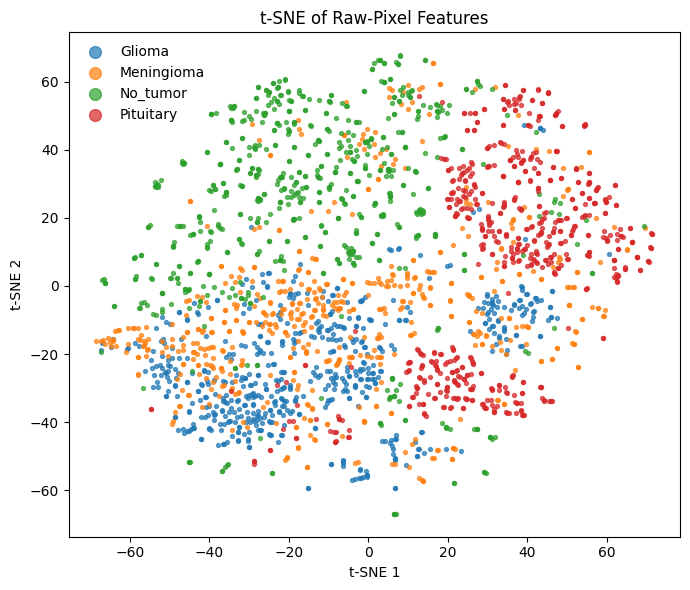

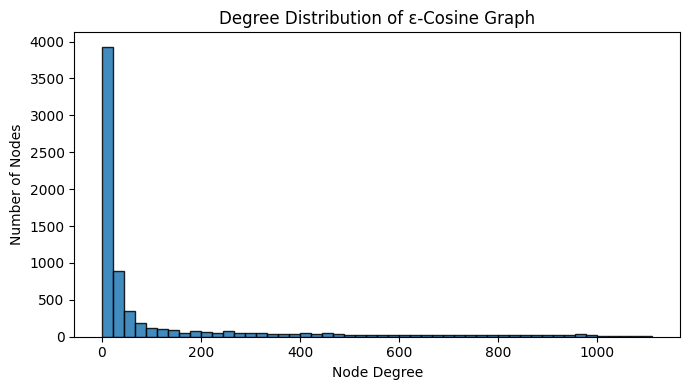

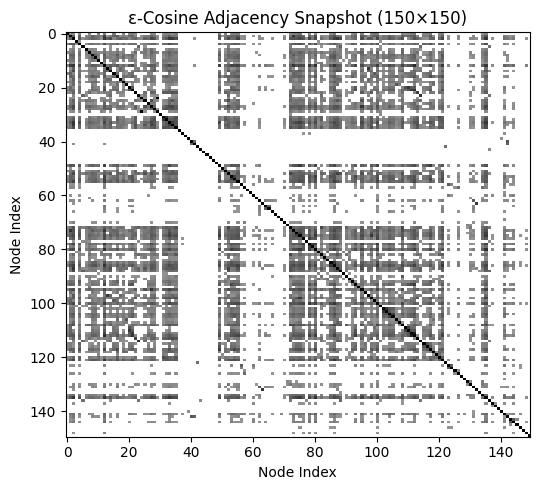


=== Training Class Weights ===
Glioma: Count=1135, Weight=1.0826
Meningioma: Count=1151, Weight=1.0675
No_tumor: Count=1400, Weight=0.8777
Pituitary: Count=1229, Weight=0.9998
Model: "GCN_Epsilon_Cosine"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 X_in (InputLayer)              [(None, 37632)]      0           []                               
                                                                                                  
 A_in (InputLayer)              [(None, 7023)]       0           []                               
                                                                                                  
 GCN_1 (GCNConv)                (None, 64)           2408512     ['X_in[0][0]',                   
                                                                  'A_in[0][0]']                   
   

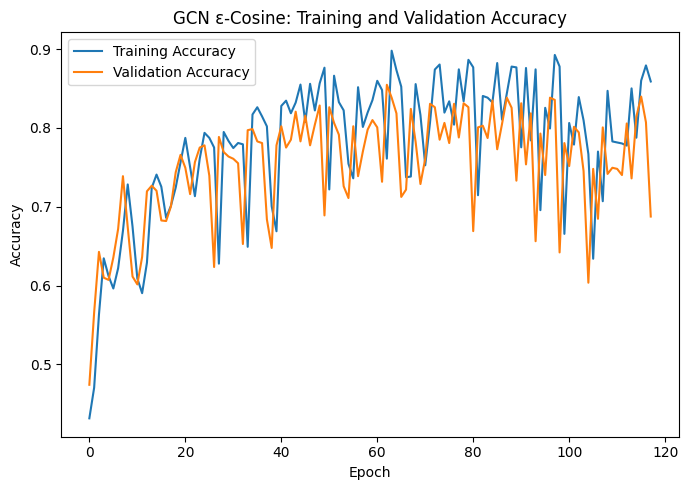

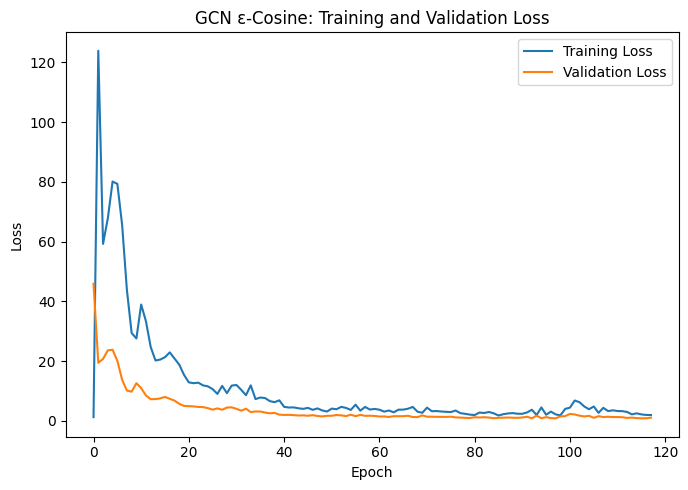


[STEP 6] Generating predictions...
[TIME] Full-graph inference: 1.9950 seconds

VALIDATION RESULTS
Loss     : 0.8051
Accuracy : 0.8356

[VALIDATION] Classification Report:
              precision    recall  f1-score   support

      Glioma     0.7592    0.8951    0.8215       324
  Meningioma     0.7653    0.6839    0.7223       329
    No_tumor     0.9284    0.8425    0.8834       400
   Pituitary     0.8798    0.9148    0.8969       352

    accuracy                         0.8356      1405
   macro avg     0.8332    0.8341    0.8310      1405
weighted avg     0.8390    0.8356    0.8348      1405

[VALIDATION] Confusion Matrix:
[[290  28   1   5]
 [ 66 225  21  17]
 [  8  33 337  22]
 [ 18   8   4 322]]


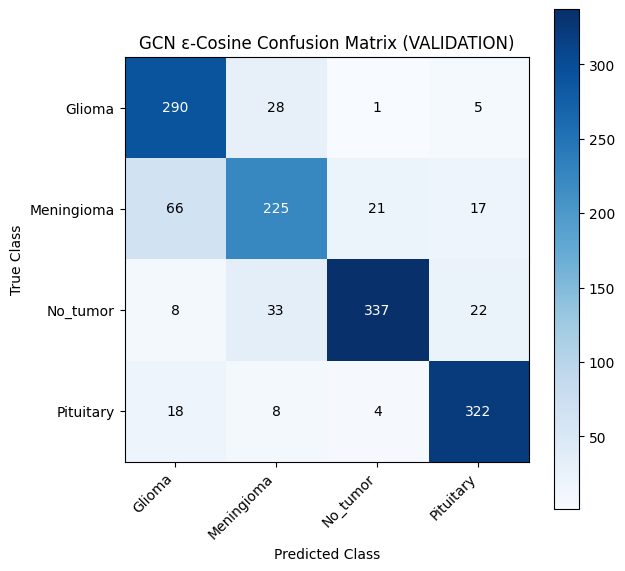

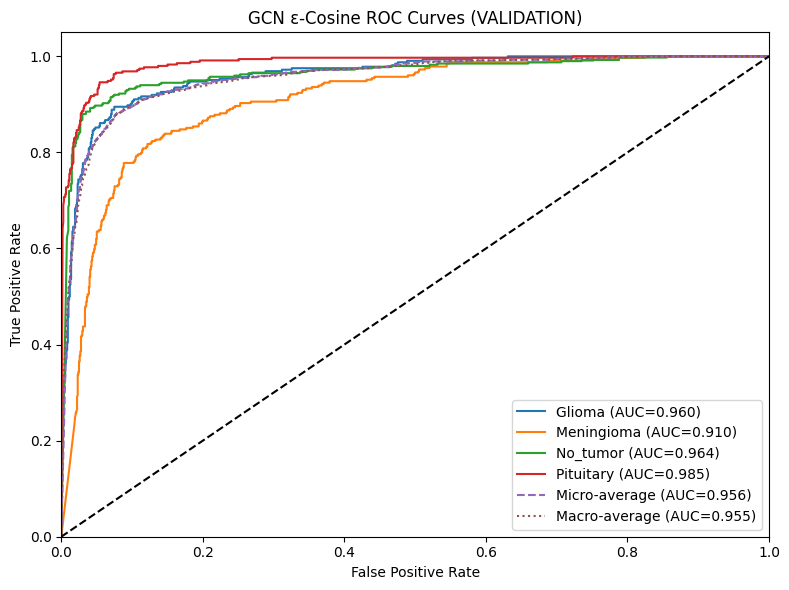


[VALIDATION] AUC:
Glioma: 0.9601
Meningioma: 0.9096
No_tumor: 0.9644
Pituitary: 0.9849
Micro-average: 0.9557
Macro-average: 0.9551

TEST RESULTS
Loss     : 0.5072
Accuracy : 0.8293

[TEST] Classification Report:
              precision    recall  f1-score   support

      Glioma     0.7413    0.9198    0.8209       162
  Meningioma     0.7296    0.7030    0.7160       165
    No_tumor     0.9274    0.8300    0.8760       200
   Pituitary     0.9268    0.8636    0.8941       176

    accuracy                         0.8293       703
   macro avg     0.8313    0.8291    0.8268       703
weighted avg     0.8379    0.8293    0.8303       703

[TEST] Confusion Matrix:
[[149  11   1   1]
 [ 31 116  12   6]
 [  4  25 166   5]
 [ 17   7   0 152]]


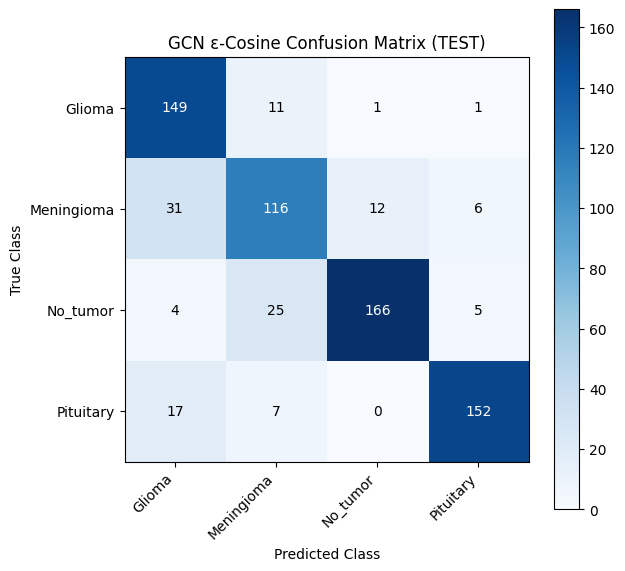

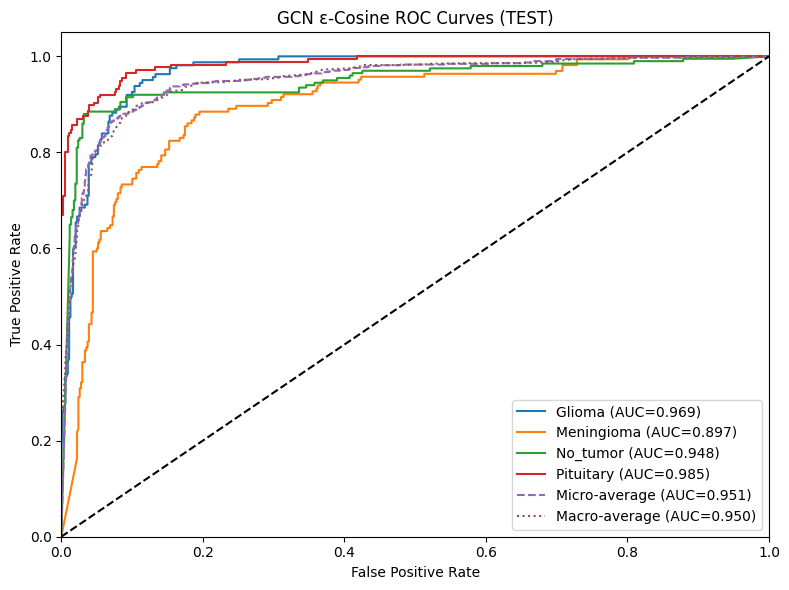


[TEST] AUC:
Glioma: 0.9689
Meningioma: 0.8974
No_tumor: 0.9477
Pituitary: 0.9846
Micro-average: 0.9507
Macro-average: 0.9504

GCN_Epsilon_Cosine FINAL SUMMARY
Model name           : GCN_Epsilon_Cosine
Input image size     : 112 × 112 × 3
Raw feature dim      : 37632
Number of nodes      : 7023
Training nodes       : 4915
Validation nodes     : 1405
Test nodes           : 703
Dataset split        : 70% / 20% / 10%
Cosine threshold ε   : 0.5
Cosine radius        : 0.50
Neighbour metric     : Cosine
Edge weighting       : Cosine similarity
Graph edges          : 409555
Average degree       : 116.63
Minimum degree       : 0
Maximum degree       : 1112
Graph density        : 0.016610
Graph components     : 473
Largest component    : 5908
Adjacency nnz        : 826133
Class balancing      : True
GCN hidden units     : 64
Dropout              : 0.3
Learning rate        : 0.005
Weight decay         : 0.0005
Label smoothing      : 0.05
Epochs               : 250
Trainable parameters : 4,817,47

In [ ]:
# ============================================================
# GCN_Epsilon_Cosine
# Pure GCN on RAW PIXELS — ε-Graph Using Cosine Similarity
# ============================================================

import os, glob, time
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import radius_neighbors_graph
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from scipy.sparse.csgraph import connected_components
import tensorflow as tf
from tensorflow.keras import layers, Input, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from spektral.layers import GCNConv
from spektral.utils.convolution import gcn_filter

# ============================================================
# STEP 0 — PATHS AND PARAMETERS
# ============================================================

data_dir = r"D:/GCN/Brain_Tumor/four_class"
IMG_SIZE_RAW = (112, 112)
SEED = 123
EPS_COS = 0.85
LR_GCN = 5e-3
WD = 5e-4
EPOCHS_GCN = 250
HIDDEN = 64
DROPOUT = 0.3
LABEL_SMOOTH = 0.05
TEST_SIZE = 0.10
VAL_SPLIT = 2 / 9
USE_CLASS_BALANCING = True
TSNE_MAX_N = 2500

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# STEP 1 — INDEX IMAGES AND LABELS
# ============================================================

class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
class_to_idx = {c: i for i, c in enumerate(class_names)}
paths = []
labels_int = []

for c in class_names:
    cdir = os.path.join(data_dir, c)
    for p in glob.glob(os.path.join(cdir, "*")):
        if p.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):
            paths.append(p)
            labels_int.append(class_to_idx[c])

paths = np.array(paths)
labels_int = np.array(labels_int, dtype=np.int32)
num_classes = len(class_names)

if len(paths) == 0: raise ValueError(f"No images found in {data_dir}")
if num_classes < 2: raise ValueError("At least two classes are required.")

print(f"[STEP 1] Found {len(paths)} images across {num_classes} classes:")
print(class_names)

# ============================================================
# STEP 1A — STRATIFIED 70/20/10 SPLIT
# ============================================================

all_idx = np.arange(len(paths))
idx_trainval, idx_te = train_test_split(all_idx, test_size=TEST_SIZE, random_state=SEED, stratify=labels_int)
idx_tr, idx_va = train_test_split(idx_trainval, test_size=VAL_SPLIT, random_state=SEED, stratify=labels_int[idx_trainval])

N = len(paths)
mask_tr = np.zeros(N, dtype=bool)
mask_va = np.zeros(N, dtype=bool)
mask_te = np.zeros(N, dtype=bool)
mask_tr[idx_tr] = True
mask_va[idx_va] = True
mask_te[idx_te] = True

if len(idx_tr) + len(idx_va) + len(idx_te) != N: raise ValueError("Dataset split size mismatch.")
if np.any(mask_tr & mask_va) or np.any(mask_tr & mask_te) or np.any(mask_va & mask_te): raise ValueError("Dataset split overlap detected.")

print("\n=== Dataset Split ===")
print(f"Training   : {len(idx_tr)} ({100 * len(idx_tr) / N:.2f}%)")
print(f"Validation : {len(idx_va)} ({100 * len(idx_va) / N:.2f}%)")
print(f"Testing    : {len(idx_te)} ({100 * len(idx_te) / N:.2f}%)")

print("\n=== Class Distribution ===")
for i, cname in enumerate(class_names):
    n_train = np.sum(labels_int[idx_tr] == i)
    n_val = np.sum(labels_int[idx_va] == i)
    n_test = np.sum(labels_int[idx_te] == i)
    print(f"{cname}: Train={n_train}, Validation={n_val}, Test={n_test}")

# ============================================================
# STEP 2 — LOAD RAW PIXELS
# ============================================================

def load_flat(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, IMG_SIZE_RAW, method=tf.image.ResizeMethod.BILINEAR)
    img.set_shape([IMG_SIZE_RAW[0], IMG_SIZE_RAW[1], 3])
    return tf.reshape(img, [-1])

def extract_raw_features(paths_np, batch=64):
    feats = []
    for i in range(0, len(paths_np), batch):
        pb = paths_np[i:i + batch]
        xb = tf.stack([load_flat(p) for p in pb], axis=0).numpy()
        feats.append(xb)
    return np.vstack(feats).astype(np.float32)

print("\n[STEP 2] Extracting raw-pixel features...")
t0 = time.time()
X_raw = extract_raw_features(paths)
t1 = time.time()

print(f"[TIME] Feature extraction: {(t1 - t0) / 60:.2f} minutes")

N, F = X_raw.shape

print("\n=== Raw Feature Information ===")
print(f"Nodes N = {N}")
print(f"Feature dimension F = {F}")
print(f"Image dimensions = {IMG_SIZE_RAW[0]} × {IMG_SIZE_RAW[1]} × 3")

y_onehot = to_categorical(labels_int, num_classes=num_classes).astype(np.float32)

# ============================================================
# STEP 2A — STANDARDIZATION
# ============================================================

scaler = StandardScaler(with_mean=True, with_std=True)
scaler.fit(X_raw[idx_tr])
X_std = scaler.transform(X_raw).astype(np.float32)

print("[STEP 2A] Raw-pixel features standardized using training-set statistics.")

# ============================================================
# STEP 3 — BUILD ε-GRAPH USING COSINE SIMILARITY
# ============================================================

print("\n[STEP 3] Building ε-Graph using cosine similarity...")
t2 = time.time()

radius = 1.0 - EPS_COS
A_eps = radius_neighbors_graph(X_std, radius=radius, metric="cosine", mode="distance", include_self=False, n_jobs=-1).tocsr()
A_eps.data = (1.0 - A_eps.data).astype(np.float32)
A_eps.eliminate_zeros()
A_eps = A_eps.maximum(A_eps.T)
A_eps = A_eps.tolil()
A_eps.setdiag(1.0)
A_eps = A_eps.tocsr()
A_norm = gcn_filter(A_eps).astype(np.float32)

t3 = time.time()

print(f"[TIME] Graph construction + normalization: {(t3 - t2) / 60:.2f} minutes")

# ============================================================
# STEP 3A — GRAPH STATISTICS
# ============================================================

A_no_self = A_eps.copy().tocsr()
A_no_self.setdiag(0)
A_no_self.eliminate_zeros()

degree_counts = np.diff(A_no_self.indptr)
num_edges = A_no_self.nnz // 2
avg_degree = degree_counts.mean()
min_degree = degree_counts.min()
max_degree = degree_counts.max()
graph_density = (2.0 * num_edges) / (N * (N - 1)) if N > 1 else 0.0
adjacency_nnz = A_eps.nnz
n_components, component_labels = connected_components(A_no_self, directed=False, return_labels=True)
component_sizes = np.bincount(component_labels)
largest_cc = component_sizes.max()

print("\n=== GCN_Epsilon_Cosine Graph Statistics ===")
print(f"Nodes          : {N}")
print(f"Edges          : {num_edges}")
print(f"Epsilon cosine : {EPS_COS}")
print(f"Average degree : {avg_degree:.2f}")
print(f"Minimum degree : {min_degree}")
print(f"Maximum degree : {max_degree}")
print(f"Density        : {graph_density:.6f}")
print(f"Components     : {n_components}")
print(f"LargestCC      : {largest_cc}")
print(f"nnz(A)         : {adjacency_nnz}")

# ============================================================
# STEP 3B — t-SNE OF RAW-PIXEL FEATURES
# ============================================================

print("\n[VIS] Running t-SNE on raw features...")

if N > TSNE_MAX_N:
    sel = np.random.RandomState(SEED).choice(N, TSNE_MAX_N, replace=False)
    X_for_tsne = X_std[sel]
    y_for_tsne = labels_int[sel]
else:
    X_for_tsne = X_std
    y_for_tsne = labels_int

tsne = TSNE(n_components=2, init="pca", learning_rate="auto", perplexity=30, random_state=SEED)
X_2d = tsne.fit_transform(X_for_tsne)

plt.figure(figsize=(7, 6))
for i, cname in enumerate(class_names):
    m = y_for_tsne == i
    plt.scatter(X_2d[m, 0], X_2d[m, 1], s=8, alpha=0.7, label=cname)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of Raw-Pixel Features")
plt.legend(markerscale=3, frameon=False)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 3C — DEGREE DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 4))
plt.hist(degree_counts, bins=50, edgecolor="black", alpha=0.85)
plt.xlabel("Node Degree")
plt.ylabel("Number of Nodes")
plt.title("Degree Distribution of ε-Cosine Graph")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 3D — ADJACENCY MATRIX SNAPSHOT
# ============================================================

subN = min(150, N)
A_small = A_eps[:subN, :subN].toarray()
plt.figure(figsize=(5.5, 5))
plt.imshow(A_small, cmap="Greys", interpolation="nearest", aspect="auto")
plt.xlabel("Node Index")
plt.ylabel("Node Index")
plt.title(f"ε-Cosine Adjacency Snapshot ({subN}×{subN})")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 4 — CLASS BALANCING
# ============================================================

train_counts = np.bincount(labels_int[idx_tr], minlength=num_classes).astype(np.float32)
class_w = np.ones(num_classes, dtype=np.float32)
sample_w_train = mask_tr.astype(np.float32)

if USE_CLASS_BALANCING:
    class_w = train_counts.sum() / (num_classes * np.maximum(train_counts, 1.0))
    sample_w_train = sample_w_train * class_w[labels_int]

print("\n=== Training Class Weights ===")
for i, cname in enumerate(class_names):
    print(f"{cname}: Count={int(train_counts[i])}, Weight={class_w[i]:.4f}")

# ============================================================
# STEP 5 — PURE GCN MODEL
# ============================================================

X_in = Input(shape=(X_std.shape[1],), name="X_in")
A_in = Input(shape=(N,), sparse=True, name="A_in")
h1 = GCNConv(HIDDEN, activation=None, kernel_regularizer=regularizers.l2(WD), name="GCN_1")([X_in, A_in])
h1 = layers.BatchNormalization(name="BatchNorm")(h1)
h1 = layers.Activation("relu", name="ReLU")(h1)
h1 = layers.Dropout(DROPOUT, name="Dropout")(h1)
res = layers.Dense(HIDDEN, use_bias=False, name="Residual_Projection")(X_in)
h1 = layers.Add(name="Residual_Add")([h1, res])
out = GCNConv(num_classes, activation="softmax", name="GCN_Output")([h1, A_in])
gcn = Model(inputs=[X_in, A_in], outputs=out, name="GCN_Epsilon_Cosine")

gcn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR_GCN), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH), weighted_metrics=["accuracy"])
gcn.summary()

# ============================================================
# STEP 5A — CALLBACKS
# ============================================================

ckpt_gcn = "best_GCN_Epsilon_Cosine.keras"
callbacks_gcn = [EarlyStopping(monitor="val_loss", patience=20, mode="min", restore_best_weights=True, verbose=1), ModelCheckpoint(ckpt_gcn, monitor="val_loss", mode="min", save_best_only=True, verbose=1)]

# ============================================================
# STEP 5B — TRAIN MODEL
# ============================================================

print("\n[STEP 5] Training GCN_Epsilon_Cosine...")
t4 = time.time()

hist = gcn.fit(x=[X_std, A_norm], y=y_onehot, sample_weight=sample_w_train, batch_size=N, epochs=EPOCHS_GCN, shuffle=False, verbose=1, validation_data=([X_std, A_norm], y_onehot, mask_va.astype(np.float32)), callbacks=callbacks_gcn)

t5 = time.time()
training_time = t5 - t4

print(f"\n[TIME] GCN training: {training_time / 60:.2f} minutes")

# ============================================================
# STEP 5C — TRAINING AND VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(7, 5))
plt.plot(hist.history["accuracy"], label="Training Accuracy")
plt.plot(hist.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GCN ε-Cosine: Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# STEP 5D — TRAINING AND VALIDATION LOSS
# ============================================================

plt.figure(figsize=(7, 5))
plt.plot(hist.history["loss"], label="Training Loss")
plt.plot(hist.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GCN ε-Cosine: Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# STEP 6 — PREDICTIONS
# ============================================================

print("\n[STEP 6] Generating predictions...")
t6 = time.time()
y_prob = gcn.predict([X_std, A_norm], batch_size=N, verbose=0)
t7 = time.time()

inference_time = t7 - t6
y_pred = np.argmax(y_prob, axis=1)

print(f"[TIME] Full-graph inference: {inference_time:.4f} seconds")

# ============================================================
# STEP 6A — EVALUATION FUNCTION
# ============================================================

def evaluate_mask(mask_name, mask_bool):
    loss, acc = gcn.evaluate([X_std, A_norm], y_onehot, sample_weight=mask_bool.astype(np.float32), batch_size=N, verbose=0)

    print(f"\n{'=' * 60}")
    print(f"{mask_name} RESULTS")
    print(f"{'=' * 60}")
    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {acc:.4f}")

    y_true_mask = labels_int[mask_bool]
    y_pred_mask = y_pred[mask_bool]
    y_prob_mask = y_prob[mask_bool]

    print(f"\n[{mask_name}] Classification Report:")
    print(classification_report(y_true_mask, y_pred_mask, labels=np.arange(num_classes), target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(y_true_mask, y_pred_mask, labels=np.arange(num_classes))
    print(f"[{mask_name}] Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(6.5, 6))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()
    plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
    plt.yticks(range(num_classes), class_names)
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title(f"GCN ε-Cosine Confusion Matrix ({mask_name})")
    threshold = cm.max() / 2.0 if cm.size > 0 else 0

    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, cm[i, j], ha="center", va="center", color=("white" if cm[i, j] > threshold else "black"))

    plt.tight_layout()
    plt.show()

    try:
        y_bin = label_binarize(y_true_mask, classes=np.arange(num_classes))
        if num_classes == 2: y_bin = np.column_stack([1 - y_bin[:, 0], y_bin[:, 0]])

        fpr = {}
        tpr = {}
        roc_auc = {}

        for i in range(num_classes):
            if len(np.unique(y_bin[:, i])) < 2: continue
            fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_prob_mask[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), y_prob_mask.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        valid_classes = [i for i in range(num_classes) if i in fpr]

        if len(valid_classes) > 0:
            all_fpr = np.unique(np.concatenate([fpr[i] for i in valid_classes]))
            mean_tpr = np.zeros_like(all_fpr)
            for i in valid_classes: mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
            mean_tpr /= len(valid_classes)
            fpr["macro"] = all_fpr
            tpr["macro"] = mean_tpr
            roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

        plt.figure(figsize=(8, 6))

        for i in valid_classes:
            plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC={roc_auc[i]:.3f})")

        plt.plot(fpr["micro"], tpr["micro"], linestyle="--", label=f"Micro-average (AUC={roc_auc['micro']:.3f})")

        if "macro" in fpr:
            plt.plot(fpr["macro"], tpr["macro"], linestyle=":", label=f"Macro-average (AUC={roc_auc['macro']:.3f})")

        plt.plot([0, 1], [0, 1], "k--")
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"GCN ε-Cosine ROC Curves ({mask_name})")
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()

        print(f"\n[{mask_name}] AUC:")
        for i in valid_classes: print(f"{class_names[i]}: {roc_auc[i]:.4f}")
        print(f"Micro-average: {roc_auc['micro']:.4f}")
        if "macro" in roc_auc: print(f"Macro-average: {roc_auc['macro']:.4f}")

    except Exception as e:
        print(f"[ROC] Skipped: {e}")

# ============================================================
# STEP 6B — VALIDATION AND TEST EVALUATION
# ============================================================

evaluate_mask("VALIDATION", mask_va)
evaluate_mask("TEST", mask_te)

# ============================================================
# FINAL COMPUTATIONAL INFORMATION — GCN_Epsilon_Cosine
# ============================================================

print("\n============================================================")
print("GCN_Epsilon_Cosine FINAL SUMMARY")
print("============================================================")
print(f"Model name           : {gcn.name}")
print(f"Input image size     : {IMG_SIZE_RAW[0]} × {IMG_SIZE_RAW[1]} × 3")
print(f"Raw feature dim      : {F}")
print(f"Number of nodes      : {N}")
print(f"Training nodes       : {len(idx_tr)}")
print(f"Validation nodes     : {len(idx_va)}")
print(f"Test nodes           : {len(idx_te)}")
print("Dataset split        : 70% / 20% / 10%")
print(f"Cosine threshold ε   : {EPS_COS}")
print(f"Cosine radius        : {radius:.2f}")
print("Neighbour metric     : Cosine")
print("Edge weighting       : Cosine similarity")
print(f"Graph edges          : {num_edges}")
print(f"Average degree       : {avg_degree:.2f}")
print(f"Minimum degree       : {min_degree}")
print(f"Maximum degree       : {max_degree}")
print(f"Graph density        : {graph_density:.6f}")
print(f"Graph components     : {n_components}")
print(f"Largest component    : {largest_cc}")
print(f"Adjacency nnz        : {adjacency_nnz}")
print(f"Class balancing      : {USE_CLASS_BALANCING}")
print(f"GCN hidden units     : {HIDDEN}")
print(f"Dropout              : {DROPOUT}")
print(f"Learning rate        : {LR_GCN}")
print(f"Weight decay         : {WD}")
print(f"Label smoothing      : {LABEL_SMOOTH}")
print(f"Epochs               : {EPOCHS_GCN}")
print(f"Trainable parameters : {gcn.count_params():,}")
print(f"Training time        : {training_time:.2f} seconds")
print(f"Training time        : {training_time / 60:.2f} minutes")
print(f"Inference time       : {inference_time:.4f} seconds")
print("============================================================")


***
<a name='import Packages'>
    
# 0 <span style='color:blue'>|</span> COMPLETE MEMORY / CACHE / VARIABLE CLEANUP

In [9]:
import os, gc, time, psutil

def get_user_variables():
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None: return {}
        excluded = {"In", "Out", "get_ipython", "exit", "quit"}
        return {name: value for name, value in ip.user_ns.items() if not name.startswith("_") and name not in excluded}
    except Exception:
        return {}
def get_ram_usage():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**2
def print_variable_information():
    variables = get_user_variables()
    print(f"Variable count  : {len(variables)}")
    if variables: print("Variables       : " + ", ".join(sorted(variables.keys())))
def clear_matplotlib_cache():
    try:
        import matplotlib.pyplot as plt
        print("\n[1] Closing Matplotlib figures...")
        plt.close("all")
        print("    Matplotlib figures closed.")
    except ImportError:
        print("\n[1] Matplotlib not installed.")
    except Exception as e:
        print(f"\n[1] Matplotlib warning: {e}")
def clear_tensorflow_memory():
    try:
        import tensorflow as tf
        print("\n[2] Clearing TensorFlow / Keras...")
        tf.keras.backend.clear_session()
        print("    Keras session cleared.")
        gpus = tf.config.list_physical_devices("GPU")
        if gpus:
            for i in range(len(gpus)):
                try:
                    info = tf.config.experimental.get_memory_info(f"GPU:{i}")
                    print(f"    GPU:{i} current: {info['current']/1024**2:.2f} MB")
                    print(f"    GPU:{i} peak   : {info['peak']/1024**2:.2f} MB")
                except Exception:
                    pass
                try: tf.config.experimental.reset_memory_stats(f"GPU:{i}")
                except Exception: pass
        print("    TensorFlow cleanup completed.")
    except ImportError:
        print("\n[2] TensorFlow not installed.")
    except Exception as e:
        print(f"\n[2] TensorFlow warning: {e}")
def force_garbage_collection(cycles=3):
    print("\n[3] Running garbage collection...")
    total = sum(gc.collect() for _ in range(cycles))
    print(f"    Garbage-collected objects: {total}")
def delete_model_variables():
    print("\n[4] Deleting user/model/data variables...")
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None:
            print("    Not running inside Jupyter.")
            return 0, []
        protected = {"os", "gc", "time", "psutil", "get_user_variables", "get_ram_usage", "print_variable_information", "clear_matplotlib_cache", "clear_tensorflow_memory", "force_garbage_collection", "delete_model_variables", "clear_cache_and_memory", "In", "Out", "get_ipython", "exit", "quit"}
        names = [name for name in list(ip.user_ns.keys()) if not name.startswith("_") and name not in protected]
        print(f"    Variables selected for deletion: {len(names)}")
        if names: print("    Deleting: " + ", ".join(sorted(names)))
        deleted = 0
        for name in names:
            try:
                del ip.user_ns[name]
                deleted += 1
            except Exception as e:
                print(f"    Could not delete {name}: {e}")
        print(f"    Successfully deleted: {deleted}")
        return deleted, names
    except Exception as e:
        print(f"    Variable cleanup warning: {e}")
        return 0, []
def clear_cache_and_memory():
    print("\n" + "=" * 70)
    print("COMPLETE MEMORY / CACHE / VARIABLE CLEANUP")
    print("=" * 70)
    before_ram = get_ram_usage()
    before_variables = get_user_variables()
    before_count = len(before_variables)
    print("\nBEFORE CLEANING")
    print("-" * 70)
    print(f"RAM usage       : {before_ram:.2f} MB")
    print(f"Variable count  : {before_count}")
    if before_variables: print("Variables       : " + ", ".join(sorted(before_variables.keys())))
    clear_matplotlib_cache()
    clear_tensorflow_memory()
    force_garbage_collection()
    deleted_count, deleted_names = delete_model_variables()
    print("\n[5] Final garbage collection...")
    total = sum(gc.collect() for _ in range(5))
    print(f"    Garbage-collected objects: {total}")
    time.sleep(1)
    after_ram = get_ram_usage()
    after_variables = get_user_variables()
    after_count = len(after_variables)
    print("\nAFTER CLEANING")
    print("-" * 70)
    print(f"RAM usage       : {after_ram:.2f} MB")
    print(f"Variable count  : {after_count}")
    if after_variables: print("Remaining       : " + ", ".join(sorted(after_variables.keys())))
    ram_difference = before_ram - after_ram
    print("\n" + "=" * 70)
    print("CLEANUP SUMMARY")
    print("=" * 70)
    print(f"Variables before : {before_count}")
    print(f"Variables after  : {after_count}")
    print(f"Variables deleted: {deleted_count}")
    print("-" * 70)
    print(f"RAM before       : {before_ram:.2f} MB")
    print(f"RAM after        : {after_ram:.2f} MB")
    if ram_difference >= 0: print(f"RAM released     : {ram_difference:.2f} MB")
    else: print(f"RAM difference   : +{abs(ram_difference):.2f} MB")
    print("=" * 70)
    print("CLEANUP COMPLETED")
    print("=" * 70)
clear_cache_and_memory()


COMPLETE MEMORY / CACHE / VARIABLE CLEANUP

BEFORE CLEANING
----------------------------------------------------------------------
RAM usage       : 5092.74 MB
Variable count  : 78
Variables       : DROPOUT, EPOCHS_GCN, EarlyStopping, GCNConv, HIDDEN, IMG_SIZE_RAW, Input, K_RBF, LABEL_SMOOTH, LR_GCN, MIN_WEIGHT, Model, ModelCheckpoint, N, NearestNeighbors, SEED, SIGMA_FIXED, SIGMA_MODE, StandardScaler, TEST_SIZE, TSNE, TSNE_MAX_N, USE_CLASS_BALANCING, VAL_SPLIT, WD, all_idx, auc, c, cdir, class_names, class_to_idx, classification_report, clear_cache_and_memory, clear_matplotlib_cache, clear_tensorflow_memory, cname, confusion_matrix, connected_components, data_dir, delete_model_variables, extract_raw_features, force_garbage_collection, gc, gcn_filter, get_ram_usage, get_user_variables, glob, i, idx_te, idx_tr, idx_trainval, idx_va, label_binarize, labels_int, layers, load_flat, mask_te, mask_tr, mask_va, n_test, n_train, n_val, np, num_classes, os, p, paths, plt, print_variable_inform


***
<a name='import Packages'>
    
# 4 <span style='color:blue'>|</span> GCN_RBF on Pure GCN on RAW PIXELS

[STEP 1] Found 7023 images across 4 classes:
['Glioma', 'Meningioma', 'No_tumor', 'Pituitary']

=== Dataset Split ===
Training   : 4915 (69.98%)
Validation : 1405 (20.01%)
Testing    : 703 (10.01%)

=== Class Distribution ===
Glioma: Train=1135, Validation=324, Test=162
Meningioma: Train=1151, Validation=329, Test=165
No_tumor: Train=1400, Validation=400, Test=200
Pituitary: Train=1229, Validation=352, Test=176

[STEP 2] Extracting raw-pixel features...
[TIME] Feature extraction: 0.38 minutes

=== Raw Feature Information ===
Nodes N = 7023
Feature dimension F = 37632
Image dimensions = 112 × 112 × 3
[STEP 2A] Raw-pixel features standardized using training-set statistics.

[STEP 3] Building RBF-Cosine graph...
[RBF-Cosine] Sigma = 0.392677
[TIME] RBF-Cosine graph + normalization: 0.90 minutes

=== GCN_RBF Graph Statistics ===
Nodes          : 7023
Edges          : 61910
RBF K          : 12
Average degree : 17.63
Minimum degree : 12
Maximum degree : 303
Density        : 0.002511
Componen

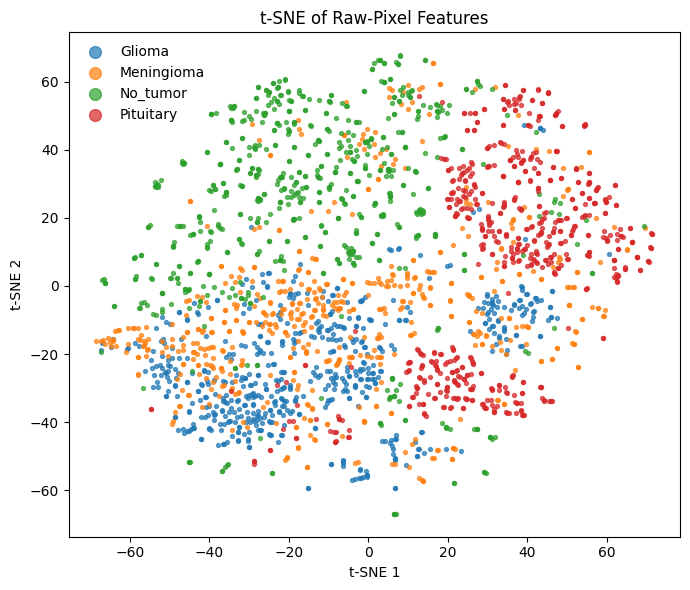

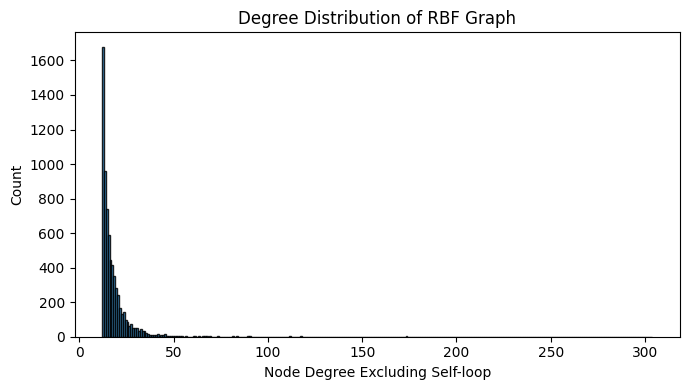

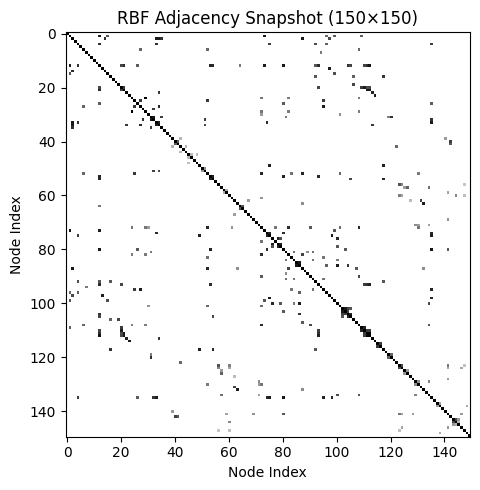


=== Training Class Weights ===
Glioma: Count=1135, Weight=1.0826
Meningioma: Count=1151, Weight=1.0675
No_tumor: Count=1400, Weight=0.8777
Pituitary: Count=1229, Weight=0.9998
Model: "GCN_RBF"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 X_in (InputLayer)              [(None, 37632)]      0           []                               
                                                                                                  
 A_in (InputLayer)              [(None, 7023)]       0           []                               
                                                                                                  
 GCN_1 (GCNConv)                (None, 64)           2408512     ['X_in[0][0]',                   
                                                                  'A_in[0][0]']                   
              

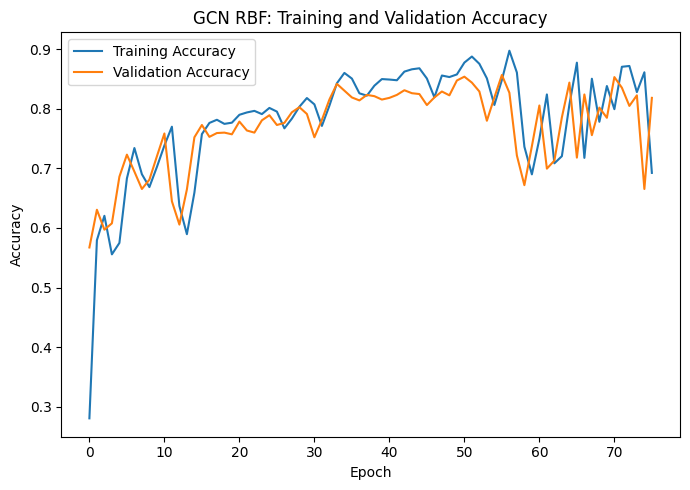

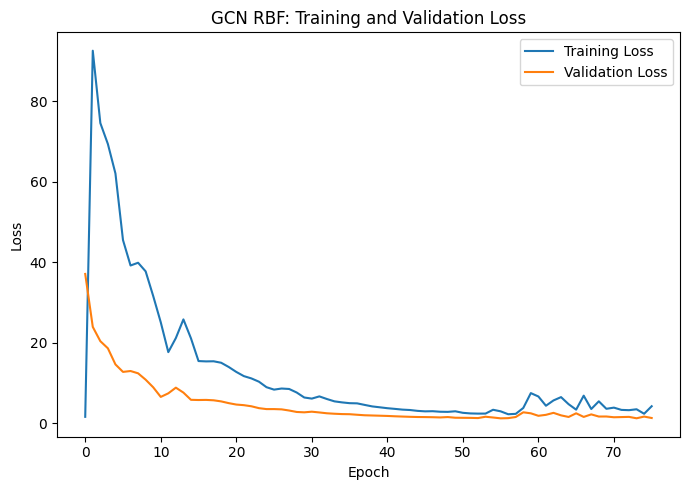


[STEP 6] Generating predictions...
[TIME] Full-graph inference: 1.1652 seconds

VALIDATION RESULTS
Loss     : 1.2129
Accuracy : 0.8569

[VALIDATION] Classification Report:
              precision    recall  f1-score   support

      Glioma     0.7277    0.8827    0.7978       324
  Meningioma     0.7931    0.6991    0.7431       329
    No_tumor     0.9529    0.9100    0.9309       400
   Pituitary     0.9529    0.9205    0.9364       352

    accuracy                         0.8569      1405
   macro avg     0.8567    0.8531    0.8521      1405
weighted avg     0.8636    0.8569    0.8576      1405

[VALIDATION] Confusion Matrix:
[[286  35   0   3]
 [ 71 230  17  11]
 [ 21  13 364   2]
 [ 15  12   1 324]]


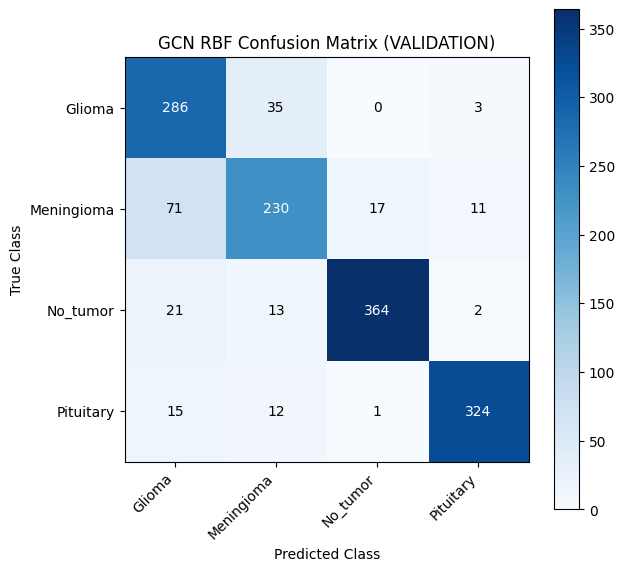

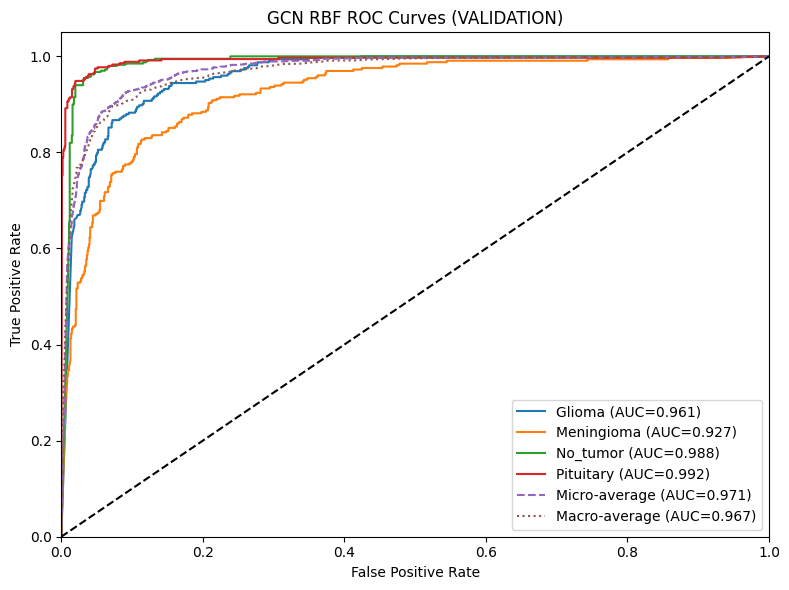


[VALIDATION] AUC:
Glioma: 0.9614
Meningioma: 0.9269
No_tumor: 0.9876
Pituitary: 0.9918
Micro-average: 0.9706
Macro-average: 0.9673

TEST RESULTS
Loss     : 0.9228
Accuracy : 0.8336

[TEST] Classification Report:
              precision    recall  f1-score   support

      Glioma     0.6820    0.9136    0.7810       162
  Meningioma     0.8403    0.6061    0.7042       165
    No_tumor     0.9239    0.9100    0.9169       200
   Pituitary     0.9176    0.8864    0.9017       176

    accuracy                         0.8336       703
   macro avg     0.8410    0.8290    0.8260       703
weighted avg     0.8470    0.8336    0.8319       703

[TEST] Confusion Matrix:
[[148  10   0   4]
 [ 43 100  15   7]
 [ 11   4 182   3]
 [ 15   5   0 156]]


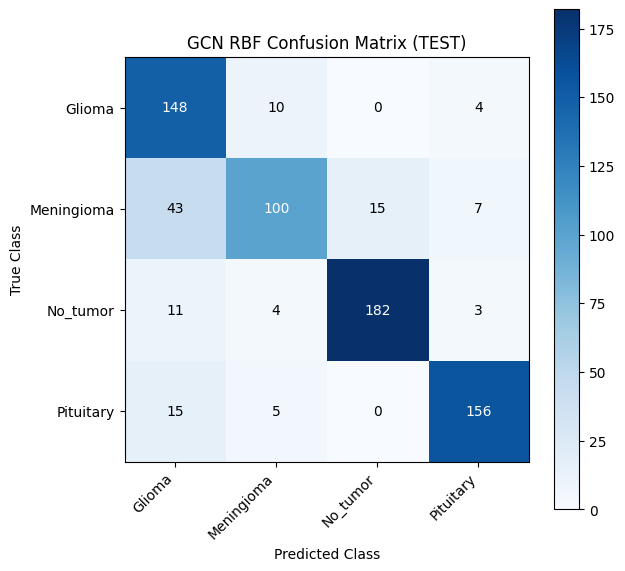

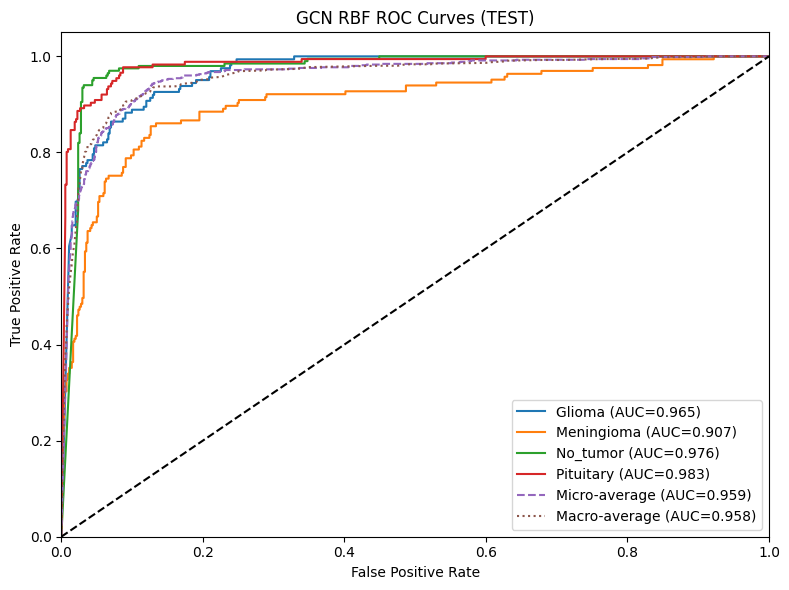


[TEST] AUC:
Glioma: 0.9650
Meningioma: 0.9071
No_tumor: 0.9757
Pituitary: 0.9829
Micro-average: 0.9592
Macro-average: 0.9584

GCN_RBF FINAL SUMMARY
Graph               : RBF-Cosine
RBF K               : 12
RBF sigma           : 0.392677
Sigma mode          : auto
Neighbour metric    : Cosine
Distance            : Cosine distance
Edge weighting      : Gaussian RBF
Weight formula      : exp(-d_cosine^2 / (2*sigma^2))
Symmetrization      : A.maximum(A.T)
Self loops          : Yes
GCN normalization   : gcn_filter


In [10]:
import os, glob, time
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from scipy.sparse.csgraph import connected_components
import tensorflow as tf
from tensorflow.keras import layers, Input, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from spektral.layers import GCNConv
from spektral.utils.convolution import gcn_filter

# ============================================================
# STEP 0 — PATHS AND PARAMETERS
# ============================================================

data_dir = r"D:/GCN/Brain_Tumor/four_class"
IMG_SIZE_RAW = (112, 112)
SEED = 123
K_RBF = 12
SIGMA_MODE = "auto"
SIGMA_FIXED = 1.0
MIN_WEIGHT = 1e-6
LR_GCN = 5e-3
WD = 5e-4
EPOCHS_GCN = 250
HIDDEN = 64
DROPOUT = 0.3
LABEL_SMOOTH = 0.05
TEST_SIZE = 0.10
VAL_SPLIT = 2 / 9
USE_CLASS_BALANCING = True
TSNE_MAX_N = 2500

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ============================================================
# STEP 1 — INDEX IMAGES AND LABELS
# ============================================================

class_names = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
class_to_idx = {c: i for i, c in enumerate(class_names)}
paths = []
labels_int = []

for c in class_names:
    cdir = os.path.join(data_dir, c)
    for p in glob.glob(os.path.join(cdir, "*")):
        if p.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):
            paths.append(p)
            labels_int.append(class_to_idx[c])

paths = np.array(paths)
labels_int = np.array(labels_int, dtype=np.int32)
num_classes = len(class_names)

if len(paths) == 0: raise ValueError(f"No images found in {data_dir}")
if num_classes < 2: raise ValueError("At least two classes are required.")

print(f"[STEP 1] Found {len(paths)} images across {num_classes} classes:")
print(class_names)

# ============================================================
# STEP 1A — STRATIFIED 70/20/10 SPLIT
# ============================================================

all_idx = np.arange(len(paths))
idx_trainval, idx_te = train_test_split(all_idx, test_size=TEST_SIZE, random_state=SEED, stratify=labels_int)
idx_tr, idx_va = train_test_split(idx_trainval, test_size=VAL_SPLIT, random_state=SEED, stratify=labels_int[idx_trainval])

N = len(paths)
mask_tr = np.zeros(N, dtype=bool)
mask_va = np.zeros(N, dtype=bool)
mask_te = np.zeros(N, dtype=bool)
mask_tr[idx_tr] = True
mask_va[idx_va] = True
mask_te[idx_te] = True

if len(idx_tr) + len(idx_va) + len(idx_te) != N: raise ValueError("Dataset split size mismatch.")
if np.any(mask_tr & mask_va) or np.any(mask_tr & mask_te) or np.any(mask_va & mask_te): raise ValueError("Dataset split overlap detected.")

print("\n=== Dataset Split ===")
print(f"Training   : {len(idx_tr)} ({100 * len(idx_tr) / N:.2f}%)")
print(f"Validation : {len(idx_va)} ({100 * len(idx_va) / N:.2f}%)")
print(f"Testing    : {len(idx_te)} ({100 * len(idx_te) / N:.2f}%)")

print("\n=== Class Distribution ===")
for i, cname in enumerate(class_names):
    n_train = np.sum(labels_int[idx_tr] == i)
    n_val = np.sum(labels_int[idx_va] == i)
    n_test = np.sum(labels_int[idx_te] == i)
    print(f"{cname}: Train={n_train}, Validation={n_val}, Test={n_test}")

# ============================================================
# STEP 2 — LOAD RAW PIXELS
# ============================================================

def load_flat(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, IMG_SIZE_RAW, method=tf.image.ResizeMethod.BILINEAR)
    img.set_shape([IMG_SIZE_RAW[0], IMG_SIZE_RAW[1], 3])
    return tf.reshape(img, [-1])

def extract_raw_features(paths_np, batch=64):
    feats = []
    for i in range(0, len(paths_np), batch):
        pb = paths_np[i:i + batch]
        xb = tf.stack([load_flat(p) for p in pb], axis=0).numpy()
        feats.append(xb)
    return np.vstack(feats).astype(np.float32)

print("\n[STEP 2] Extracting raw-pixel features...")
t0 = time.time()
X_raw = extract_raw_features(paths)
t1 = time.time()

print(f"[TIME] Feature extraction: {(t1 - t0) / 60:.2f} minutes")

N, F = X_raw.shape

print("\n=== Raw Feature Information ===")
print(f"Nodes N = {N}")
print(f"Feature dimension F = {F}")
print(f"Image dimensions = {IMG_SIZE_RAW[0]} × {IMG_SIZE_RAW[1]} × 3")

y_onehot = to_categorical(labels_int, num_classes=num_classes).astype(np.float32)

# ============================================================
# STEP 2A — STANDARDIZATION
# ============================================================

scaler = StandardScaler(with_mean=True, with_std=True)
scaler.fit(X_raw[idx_tr])
X_std = scaler.transform(X_raw).astype(np.float32)

print("[STEP 2A] Raw-pixel features standardized using training-set statistics.")

# ============================================================
# STEP 3 — BUILD RBF GRAPH
# ============================================================
# ============================================================
# STEP 3 — BUILD RBF-COSINE GRAPH
# ============================================================

print("\n[STEP 3] Building RBF-Cosine graph...")
t2 = time.time()

nbrs = NearestNeighbors(
    n_neighbors=K_RBF + 1,
    metric="cosine",
    n_jobs=-1
)

nbrs.fit(X_std)
distances, indices = nbrs.kneighbors(X_std, return_distance=True)

# ============================================================
# STEP 3A — ESTIMATE SIGMA
# ============================================================

if SIGMA_MODE == "auto":
    nonzero_distances = distances[:, 1:].reshape(-1)
    nonzero_distances = nonzero_distances[nonzero_distances > 0]
    sigma_rbf = float(np.median(nonzero_distances))
else:
    sigma_rbf = float(SIGMA_FIXED)

sigma_rbf = max(sigma_rbf, 1e-8)

print(f"[RBF-Cosine] Sigma = {sigma_rbf:.6f}")

# ============================================================
# STEP 3B — RBF WEIGHTS
# ============================================================

rows = []
cols = []
data = []

denominator = 2.0 * sigma_rbf * sigma_rbf

for i in range(N):
    for j, distance in zip(indices[i], distances[i]):

        if i == j:
            continue

        weight = np.exp(
            -(float(distance) ** 2) / denominator
        )

        if weight < MIN_WEIGHT:
            continue

        rows.append(i)
        cols.append(j)
        data.append(weight)

# ============================================================
# STEP 3C — CREATE SPARSE ADJACENCY MATRIX
# ============================================================

A_dir = sp.coo_matrix(
    (
        np.asarray(data, dtype=np.float32),
        (
            np.asarray(rows, dtype=np.int32),
            np.asarray(cols, dtype=np.int32)
        )
    ),
    shape=(N, N),
    dtype=np.float32
).tocsr()

A_rbf = A_dir.maximum(A_dir.T)

A_rbf.setdiag(1.0)
A_rbf.eliminate_zeros()

A_norm = gcn_filter(A_rbf).astype(np.float32)

t3 = time.time()

print(
    f"[TIME] RBF-Cosine graph + normalization: "
    f"{(t3 - t2) / 60:.2f} minutes"
)


# ============================================================
# STEP 3D — GRAPH STATISTICS
# ============================================================

A_no_self = A_rbf.copy().tocsr()
A_no_self.setdiag(0)
A_no_self.eliminate_zeros()

degree_counts = np.diff(A_no_self.indptr)
num_edges = A_no_self.nnz // 2
avg_degree = degree_counts.mean()
min_degree = degree_counts.min()
max_degree = degree_counts.max()
graph_density = (2.0 * num_edges) / (N * (N - 1)) if N > 1 else 0.0
adjacency_nnz = A_rbf.nnz
n_components, component_labels = connected_components(A_no_self, directed=False, return_labels=True)
component_sizes = np.bincount(component_labels)
largest_cc = component_sizes.max()

print("\n=== GCN_RBF Graph Statistics ===")
print(f"Nodes          : {N}")
print(f"Edges          : {num_edges}")
print(f"RBF K          : {K_RBF}")
print(f"Average degree : {avg_degree:.2f}")
print(f"Minimum degree : {min_degree}")
print(f"Maximum degree : {max_degree}")
print(f"Density        : {graph_density:.6f}")
print(f"Components     : {n_components}")
print(f"LargestCC      : {largest_cc}")
print(f"nnz(A)         : {adjacency_nnz}")

# ============================================================
# STEP 3E — t-SNE OF RAW FEATURES
# ============================================================

print("\n[VIS] Running t-SNE on raw features...")

if N > TSNE_MAX_N:
    sel = np.random.RandomState(SEED).choice(N, TSNE_MAX_N, replace=False)
    X_for_tsne = X_std[sel]
    y_for_tsne = labels_int[sel]
else:
    X_for_tsne = X_std
    y_for_tsne = labels_int

tsne = TSNE(n_components=2, init="pca", learning_rate="auto", perplexity=30, random_state=SEED)
X_2d = tsne.fit_transform(X_for_tsne)

plt.figure(figsize=(7, 6))
for i, cname in enumerate(class_names):
    m = y_for_tsne == i
    plt.scatter(X_2d[m, 0], X_2d[m, 1], s=8, alpha=0.7, label=cname)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of Raw-Pixel Features")
plt.legend(markerscale=3, frameon=False)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 3F — RBF DEGREE DISTRIBUTION
# ============================================================

plt.figure(figsize=(7, 4))
plt.hist(degree_counts, bins=range(int(degree_counts.min()), int(degree_counts.max()) + 2), edgecolor="black", alpha=0.85)
plt.xlabel("Node Degree Excluding Self-loop")
plt.ylabel("Count")
plt.title("Degree Distribution of RBF Graph")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 3G — RBF ADJACENCY SNAPSHOT
# ============================================================

subN = min(150, N)
A_small = A_rbf[:subN, :subN].toarray()
plt.figure(figsize=(5.5, 5))
plt.imshow(A_small, cmap="Greys", interpolation="nearest")
plt.xlabel("Node Index")
plt.ylabel("Node Index")
plt.title(f"RBF Adjacency Snapshot ({subN}×{subN})")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 4 — CLASS BALANCING
# ============================================================

train_counts = np.bincount(labels_int[idx_tr], minlength=num_classes).astype(np.float32)
class_w = np.ones(num_classes, dtype=np.float32)
sample_w_train = mask_tr.astype(np.float32)

if USE_CLASS_BALANCING:
    class_w = train_counts.sum() / (num_classes * np.maximum(train_counts, 1.0))
    sample_w_train = sample_w_train * class_w[labels_int]

print("\n=== Training Class Weights ===")
for i, cname in enumerate(class_names):
    print(f"{cname}: Count={int(train_counts[i])}, Weight={class_w[i]:.4f}")

# ============================================================
# STEP 5 — PURE GCN MODEL
# ============================================================

X_in = Input(shape=(X_std.shape[1],), name="X_in")
A_in = Input(shape=(N,), sparse=True, name="A_in")
h1 = GCNConv(HIDDEN, activation=None, kernel_regularizer=regularizers.l2(WD), name="GCN_1")([X_in, A_in])
h1 = layers.BatchNormalization(name="BatchNorm")(h1)
h1 = layers.Activation("relu", name="ReLU")(h1)
h1 = layers.Dropout(DROPOUT, name="Dropout")(h1)
res = layers.Dense(HIDDEN, use_bias=False, name="Residual_Projection")(X_in)
h1 = layers.Add(name="Residual_Add")([h1, res])
out = GCNConv(num_classes, activation="softmax", name="GCN_Output")([h1, A_in])
gcn = Model(inputs=[X_in, A_in], outputs=out, name="GCN_RBF")

gcn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LR_GCN), loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH), weighted_metrics=["accuracy"])
gcn.summary()

# ============================================================
# STEP 5A — CALLBACKS
# ============================================================

ckpt_gcn = "best_GCN_RBF.keras"
callbacks_gcn = [EarlyStopping(monitor="val_loss", patience=20, mode="min", restore_best_weights=True, verbose=1), ModelCheckpoint(ckpt_gcn, monitor="val_loss", mode="min", save_best_only=True, verbose=1)]

# ============================================================
# STEP 5B — TRAIN GCN
# ============================================================

print("\n[STEP 5] Training GCN_RBF...")
t4 = time.time()

hist = gcn.fit(x=[X_std, A_norm], y=y_onehot, sample_weight=sample_w_train, batch_size=N, epochs=EPOCHS_GCN, shuffle=False, verbose=1, validation_data=([X_std, A_norm], y_onehot, mask_va.astype(np.float32)), callbacks=callbacks_gcn)

t5 = time.time()
training_time = t5 - t4

print(f"\n[TIME] GCN training: {training_time / 60:.2f} minutes")

# ============================================================
# STEP 5C — ACCURACY CURVES
# ============================================================

plt.figure(figsize=(7, 5))
plt.plot(hist.history["accuracy"], label="Training Accuracy")
plt.plot(hist.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GCN RBF: Training and Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# STEP 5D — LOSS CURVES
# ============================================================

plt.figure(figsize=(7, 5))
plt.plot(hist.history["loss"], label="Training Loss")
plt.plot(hist.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GCN RBF: Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# STEP 6 — PREDICTIONS
# ============================================================

print("\n[STEP 6] Generating predictions...")
t6 = time.time()
y_prob = gcn.predict([X_std, A_norm], batch_size=N, verbose=0)
t7 = time.time()

inference_time = t7 - t6
y_pred = np.argmax(y_prob, axis=1)

print(f"[TIME] Full-graph inference: {inference_time:.4f} seconds")

# ============================================================
# STEP 6A — EVALUATION
# ============================================================

def evaluate_mask(mask_name, mask_bool):
    loss, acc = gcn.evaluate([X_std, A_norm], y_onehot, sample_weight=mask_bool.astype(np.float32), batch_size=N, verbose=0)

    print(f"\n{'=' * 60}")
    print(f"{mask_name} RESULTS")
    print(f"{'=' * 60}")
    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {acc:.4f}")

    y_true_mask = labels_int[mask_bool]
    y_pred_mask = y_pred[mask_bool]
    y_prob_mask = y_prob[mask_bool]

    print(f"\n[{mask_name}] Classification Report:")
    print(classification_report(y_true_mask, y_pred_mask, labels=np.arange(num_classes), target_names=class_names, digits=4, zero_division=0))

    cm = confusion_matrix(y_true_mask, y_pred_mask, labels=np.arange(num_classes))
    print(f"[{mask_name}] Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(6.5, 6))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()
    plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
    plt.yticks(range(num_classes), class_names)
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title(f"GCN RBF Confusion Matrix ({mask_name})")
    threshold = cm.max() / 2.0 if cm.size > 0 else 0

    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, cm[i, j], ha="center", va="center", color=("white" if cm[i, j] > threshold else "black"))

    plt.tight_layout()
    plt.show()

    try:
        y_bin = label_binarize(y_true_mask, classes=np.arange(num_classes))
        if num_classes == 2: y_bin = np.column_stack([1 - y_bin[:, 0], y_bin[:, 0]])

        fpr = {}
        tpr = {}
        roc_auc = {}

        for i in range(num_classes):
            if len(np.unique(y_bin[:, i])) < 2: continue
            fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_prob_mask[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), y_prob_mask.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        valid_classes = [i for i in range(num_classes) if i in fpr]

        if len(valid_classes) > 0:
            all_fpr = np.unique(np.concatenate([fpr[i] for i in valid_classes]))
            mean_tpr = np.zeros_like(all_fpr)
            for i in valid_classes: mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
            mean_tpr /= len(valid_classes)
            fpr["macro"] = all_fpr
            tpr["macro"] = mean_tpr
            roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

        plt.figure(figsize=(8, 6))

        for i in valid_classes:
            plt.plot(fpr[i], tpr[i], label=f"{class_names[i]} (AUC={roc_auc[i]:.3f})")

        plt.plot(fpr["micro"], tpr["micro"], linestyle="--", label=f"Micro-average (AUC={roc_auc['micro']:.3f})")

        if "macro" in fpr:
            plt.plot(fpr["macro"], tpr["macro"], linestyle=":", label=f"Macro-average (AUC={roc_auc['macro']:.3f})")

        plt.plot([0, 1], [0, 1], "k--")
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"GCN RBF ROC Curves ({mask_name})")
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.show()

        print(f"\n[{mask_name}] AUC:")
        for i in valid_classes: print(f"{class_names[i]}: {roc_auc[i]:.4f}")
        print(f"Micro-average: {roc_auc['micro']:.4f}")
        if "macro" in roc_auc: print(f"Macro-average: {roc_auc['macro']:.4f}")

    except Exception as e:
        print(f"[ROC] Skipped: {e}")

# ============================================================
# STEP 6B — VALIDATION AND TEST
# ============================================================

evaluate_mask("VALIDATION", mask_va)
evaluate_mask("TEST", mask_te)

# ============================================================
# FINAL COMPUTATIONAL INFORMATION — GCN_RBF
# ============================================================

print("\n============================================================")
print("GCN_RBF FINAL SUMMARY")
print("============================================================")
print("Graph               : RBF-Cosine")
print(f"RBF K               : {K_RBF}")
print(f"RBF sigma           : {sigma_rbf:.6f}")
print(f"Sigma mode          : {SIGMA_MODE}")
print("Neighbour metric    : Cosine")
print("Distance            : Cosine distance")
print("Edge weighting      : Gaussian RBF")
print("Weight formula      : exp(-d_cosine^2 / (2*sigma^2))")
print("Symmetrization      : A.maximum(A.T)")
print("Self loops          : Yes")
print("GCN normalization   : gcn_filter")


***
<a name='import Packages'>
    
# 0 <span style='color:blue'>|</span> COMPLETE MEMORY / CACHE / VARIABLE CLEANUP

In [12]:
# ============================================================
# COMPLETE MEMORY / CACHE / VARIABLE CLEANUP
# ============================================================

import os, gc, time, psutil
def get_user_variables():
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None: return {}
        excluded = {"In", "Out", "get_ipython", "exit", "quit"}
        return {name: value for name, value in ip.user_ns.items() if not name.startswith("_") and name not in excluded}
    except Exception:
        return {}
def get_ram_usage():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**2
def print_variable_information():
    variables = get_user_variables()
    print(f"Variable count  : {len(variables)}")
    if variables: print("Variables       : " + ", ".join(sorted(variables.keys())))
def clear_matplotlib_cache():
    try:
        import matplotlib.pyplot as plt
        print("\n[1] Closing Matplotlib figures...")
        plt.close("all")
        print("    Matplotlib figures closed.")
    except ImportError:
        print("\n[1] Matplotlib not installed.")
    except Exception as e:
        print(f"\n[1] Matplotlib warning: {e}")
def clear_tensorflow_memory():
    try:
        import tensorflow as tf
        print("\n[2] Clearing TensorFlow / Keras...")
        tf.keras.backend.clear_session()
        print("    Keras session cleared.")
        gpus = tf.config.list_physical_devices("GPU")
        if gpus:
            for i in range(len(gpus)):
                try:
                    info = tf.config.experimental.get_memory_info(f"GPU:{i}")
                    print(f"    GPU:{i} current: {info['current']/1024**2:.2f} MB")
                    print(f"    GPU:{i} peak   : {info['peak']/1024**2:.2f} MB")
                except Exception:
                    pass
                try: tf.config.experimental.reset_memory_stats(f"GPU:{i}")
                except Exception: pass
        print("    TensorFlow cleanup completed.")
    except ImportError:
        print("\n[2] TensorFlow not installed.")
    except Exception as e:
        print(f"\n[2] TensorFlow warning: {e}")
def force_garbage_collection(cycles=3):
    print("\n[3] Running garbage collection...")
    total = sum(gc.collect() for _ in range(cycles))
    print(f"    Garbage-collected objects: {total}")
def delete_model_variables():
    print("\n[4] Deleting user/model/data variables...")
    try:
        from IPython import get_ipython
        ip = get_ipython()
        if ip is None:
            print("    Not running inside Jupyter.")
            return 0, []
        protected = {"os", "gc", "time", "psutil", "get_user_variables", "get_ram_usage", "print_variable_information", "clear_matplotlib_cache", "clear_tensorflow_memory", "force_garbage_collection", "delete_model_variables", "clear_cache_and_memory", "In", "Out", "get_ipython", "exit", "quit"}
        names = [name for name in list(ip.user_ns.keys()) if not name.startswith("_") and name not in protected]
        print(f"    Variables selected for deletion: {len(names)}")
        if names: print("    Deleting: " + ", ".join(sorted(names)))
        deleted = 0
        for name in names:
            try:
                del ip.user_ns[name]
                deleted += 1
            except Exception as e:
                print(f"    Could not delete {name}: {e}")
        print(f"    Successfully deleted: {deleted}")
        return deleted, names
    except Exception as e:
        print(f"    Variable cleanup warning: {e}")
        return 0, []
def clear_cache_and_memory():
    print("\n" + "=" * 70)
    print("COMPLETE MEMORY / CACHE / VARIABLE CLEANUP")
    print("=" * 70)
    before_ram = get_ram_usage()
    before_variables = get_user_variables()
    before_count = len(before_variables)
    print("\nBEFORE CLEANING")
    print("-" * 70)
    print(f"RAM usage       : {before_ram:.2f} MB")
    print(f"Variable count  : {before_count}")
    if before_variables: print("Variables       : " + ", ".join(sorted(before_variables.keys())))
    clear_matplotlib_cache()
    clear_tensorflow_memory()
    force_garbage_collection()
    deleted_count, deleted_names = delete_model_variables()
    print("\n[5] Final garbage collection...")
    total = sum(gc.collect() for _ in range(5))
    print(f"    Garbage-collected objects: {total}")
    time.sleep(1)
    after_ram = get_ram_usage()
    after_variables = get_user_variables()
    after_count = len(after_variables)
    print("\nAFTER CLEANING")
    print("-" * 70)
    print(f"RAM usage       : {after_ram:.2f} MB")
    print(f"Variable count  : {after_count}")
    if after_variables: print("Remaining       : " + ", ".join(sorted(after_variables.keys())))
    ram_difference = before_ram - after_ram
    print("\n" + "=" * 70)
    print("CLEANUP SUMMARY")
    print("=" * 70)
    print(f"Variables before : {before_count}")
    print(f"Variables after  : {after_count}")
    print(f"Variables deleted: {deleted_count}")
    print("-" * 70)
    print(f"RAM before       : {before_ram:.2f} MB")
    print(f"RAM after        : {after_ram:.2f} MB")
    if ram_difference >= 0: print(f"RAM released     : {ram_difference:.2f} MB")
    else: print(f"RAM difference   : +{abs(ram_difference):.2f} MB")
    print("=" * 70)
    print("CLEANUP COMPLETED")
    print("=" * 70)
clear_cache_and_memory()


COMPLETE MEMORY / CACHE / VARIABLE CLEANUP

BEFORE CLEANING
----------------------------------------------------------------------
RAM usage       : 370.85 MB
Variable count  : 12
Variables       : clear_cache_and_memory, clear_matplotlib_cache, clear_tensorflow_memory, delete_model_variables, force_garbage_collection, gc, get_ram_usage, get_user_variables, os, print_variable_information, psutil, time

[1] Closing Matplotlib figures...
    Matplotlib figures closed.

[2] Clearing TensorFlow / Keras...
    Keras session cleared.
    GPU:0 current: 55.14 MB
    GPU:0 peak   : 55.14 MB
    TensorFlow cleanup completed.

[3] Running garbage collection...
    Garbage-collected objects: 4508

[4] Deleting user/model/data variables...
    Variables selected for deletion: 0
    Successfully deleted: 0

[5] Final garbage collection...
    Garbage-collected objects: 0

AFTER CLEANING
----------------------------------------------------------------------
RAM usage       : 385.16 MB
Variable coun


***
<a name='import Packages'>
    
# 5 <span style='color:blue'>|</span> GCN on RAW PIXELS — Domain-Specific Graph

[STEP 1] Found 7023 images across 4 classes:
['Glioma', 'Meningioma', 'No_tumor', 'Pituitary']

=== Dataset Split ===
Training   : 4915 (69.98%)
Validation : 1405 (20.01%)
Testing    : 703 (10.01%)

=== Class Distribution ===
Glioma: Train=1135, Validation=324, Test=162
Meningioma: Train=1151, Validation=329, Test=165
No_tumor: Train=1400, Validation=400, Test=200
Pituitary: Train=1229, Validation=352, Test=176

[STEP 2] Extracting raw-pixel features...
[TIME] Raw feature extraction: 0.69 minutes

[STEP 2] Extracting domain features...
Domain processed: 0
Domain processed: 500
Domain processed: 1000
Domain processed: 1500
Domain processed: 2000
Domain processed: 2500
Domain processed: 3000
Domain processed: 3500
Domain processed: 4000
Domain processed: 4500
Domain processed: 5000
Domain processed: 5500
Domain processed: 6000
Domain processed: 6500
Domain processed: 7000
Domain extraction: 1.16 min

=== Raw Feature Information ===
Nodes N = 7023
Feature dimension F = 37632
Image dimensi

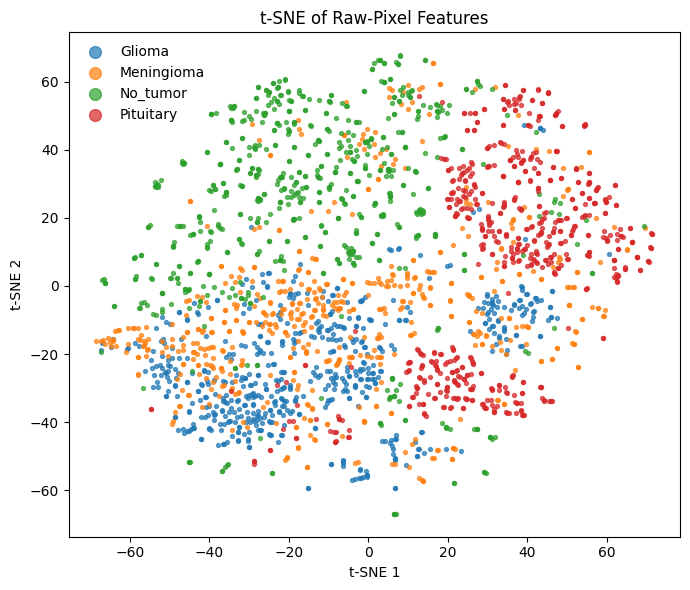

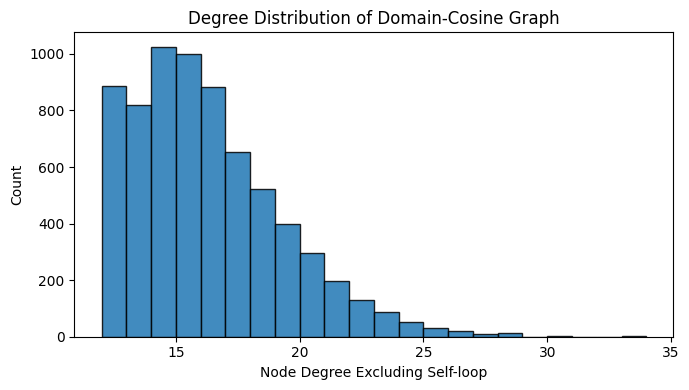

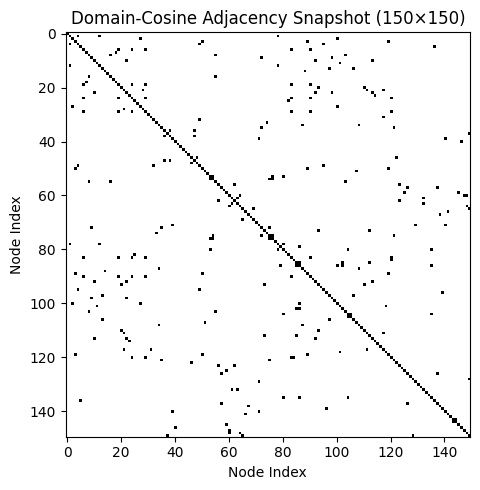


=== Training Class Weights ===
Glioma: Count=1135, Weight=1.0826
Meningioma: Count=1151, Weight=1.0675
No_tumor: Count=1400, Weight=0.8777
Pituitary: Count=1229, Weight=0.9998
Model: "GCN_Domain_Cosine"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 X_in (InputLayer)              [(None, 37632)]      0           []                               
                                                                                                  
 A_in (InputLayer)              [(None, 7023)]       0           []                               
                                                                                                  
 GCN_1 (GCNConv)                (None, 64)           2408512     ['X_in[0][0]',                   
                                                                  'A_in[0][0]']                   
    

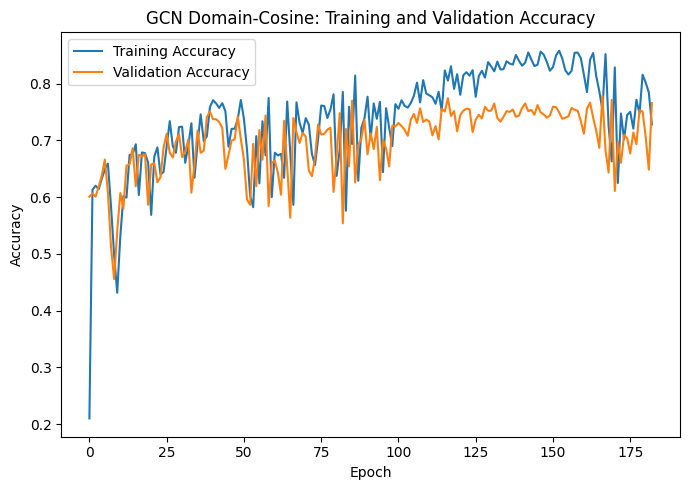

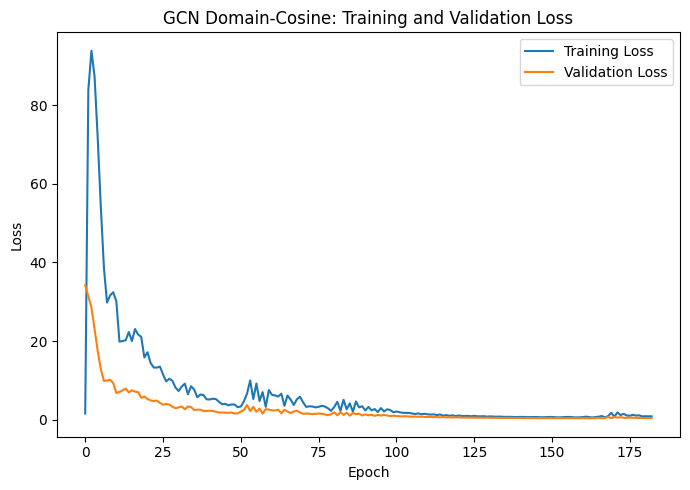


[STEP 6] Generating predictions...
[TIME] Full-graph inference: 1.1103 seconds

VALIDATION RESULTS
Loss     : 0.3439
Accuracy : 0.7665

[VALIDATION] Classification Report:
              precision    recall  f1-score   support

      Glioma     0.7321    0.6327    0.6788       324
  Meningioma     0.5824    0.6657    0.6213       329
    No_tumor     0.9030    0.9075    0.9052       400
   Pituitary     0.8357    0.8239    0.8298       352

    accuracy                         0.7665      1405
   macro avg     0.7633    0.7574    0.7588      1405
weighted avg     0.7717    0.7665    0.7676      1405

[VALIDATION] Confusion Matrix:
[[205  90   7  22]
 [ 55 219  29  26]
 [  7  21 363   9]
 [ 13  46   3 290]]


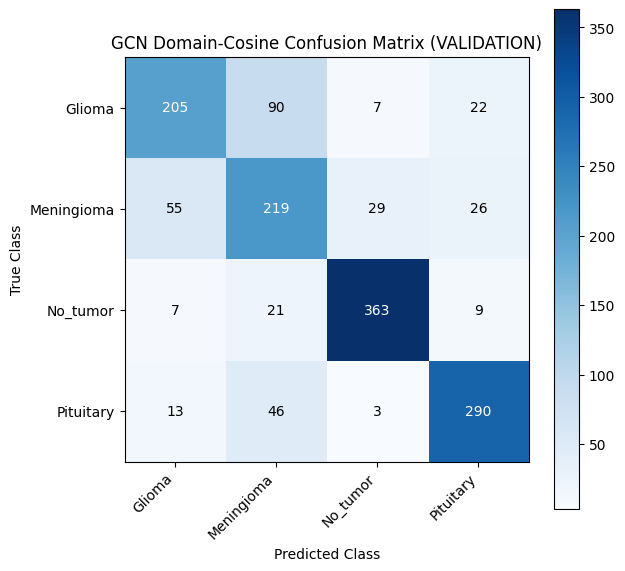

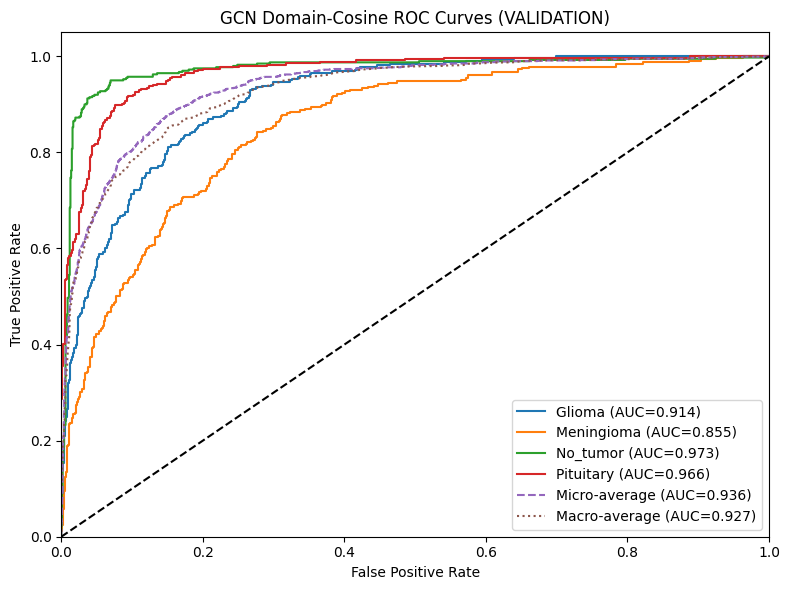


[VALIDATION] AUC:
Glioma: 0.9142
Meningioma: 0.8549
No_tumor: 0.9730
Pituitary: 0.9659
Micro-average: 0.9356
Macro-average: 0.9274

TEST RESULTS
Loss     : 0.2574
Accuracy : 0.7468

[TEST] Classification Report:
              precision    recall  f1-score   support

      Glioma     0.6980    0.6420    0.6688       162
  Meningioma     0.5787    0.6242    0.6006       165
    No_tumor     0.8500    0.9350    0.8905       200
   Pituitary     0.8397    0.7443    0.7892       176

    accuracy                         0.7468       703
   macro avg     0.7416    0.7364    0.7373       703
weighted avg     0.7487    0.7468    0.7460       703

[TEST] Confusion Matrix:
[[104  40   6  12]
 [ 30 103  23   9]
 [  3   6 187   4]
 [ 12  29   4 131]]


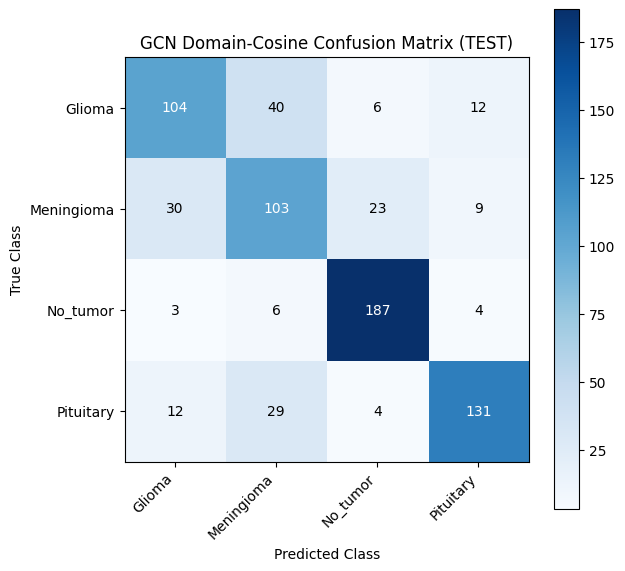

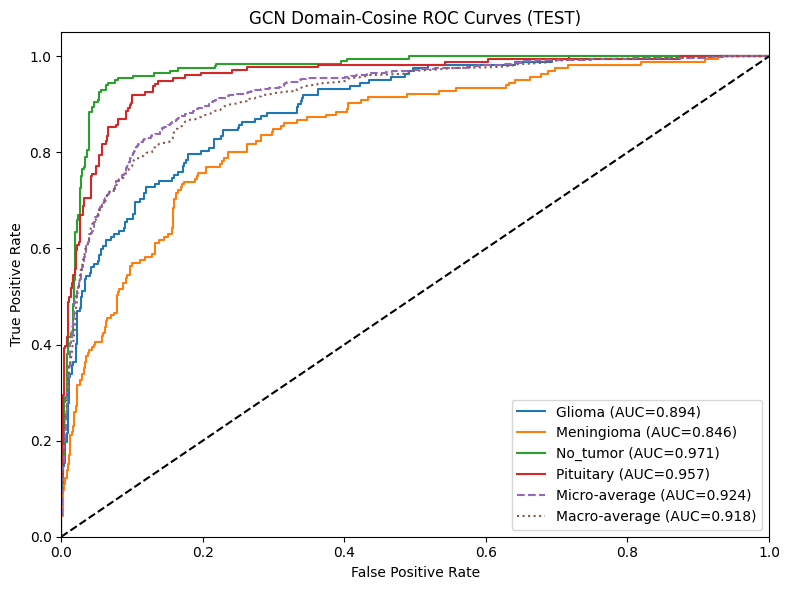


[TEST] AUC:
Glioma: 0.8940
Meningioma: 0.8457
No_tumor: 0.9711
Pituitary: 0.9566
Micro-average: 0.9241
Macro-average: 0.9177

GCN_Domain_Cosine FINAL SUMMARY
Model name           : GCN_Domain_Cosine
Input image size     : 112 × 112 × 3
Raw feature dim      : 37632
Domain feature dim   : 7
Domain image size    : 64 × 64
Number of nodes      : 7023
Training nodes       : 4915
Validation nodes     : 1405
Test nodes           : 703
Dataset split        : 70% / 20% / 10%

Graph Construction
Graph               : Domain-Cosine
Graph features      : Mean, Std, Variance, Min, Max, Edge, Entropy
Domain K             : 12
Neighbour metric     : Cosine
Edge weight          : Cosine similarity
Weight formula       : 1 - cosine distance
Symmetrization       : A.maximum(A.T)
Graph type           : Weighted
Graph direction      : Undirected
Self loops           : Yes
GCN normalization    : gcn_filter

Graph Statistics
Graph edges          : 55486
Average degree       : 15.80
Minimum degree       : 1

In [1]:
import os, glob, time
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from scipy.sparse.csgraph import connected_components

import tensorflow as tf
from tensorflow.keras import layers, Input, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from spektral.layers import GCNConv
from spektral.utils.convolution import gcn_filter


# ============================================================
# STEP 0 — PATHS AND PARAMETERS
# ============================================================

data_dir = r"D:/GCN/Brain_Tumor/four_class"

IMG_SIZE_RAW = (112, 112)
DOMAIN_SIZE = (64, 64)

SEED = 123

K_DOMAIN = 12

LR_GCN = 5e-3
WD = 5e-4
EPOCHS_GCN = 250
HIDDEN = 64
DROPOUT = 0.3
LABEL_SMOOTH = 0.05

TEST_SIZE = 0.10
VAL_SPLIT = 2 / 9

USE_CLASS_BALANCING = True
TSNE_MAX_N = 2500

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# STEP 1 — INDEX IMAGES AND LABELS
# ============================================================

class_names = sorted([
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d))
])

class_to_idx = {
    c: i for i, c in enumerate(class_names)
}

paths = []
labels_int = []

for c in class_names:

    cdir = os.path.join(data_dir, c)

    for p in glob.glob(os.path.join(cdir, "*")):

        if p.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
        ):

            paths.append(p)
            labels_int.append(class_to_idx[c])

paths = np.asarray(paths)

labels_int = np.asarray(
    labels_int,
    dtype=np.int32
)

num_classes = len(class_names)

if len(paths) == 0:
    raise ValueError(
        f"No images found in {data_dir}"
    )

if num_classes < 2:
    raise ValueError(
        "At least two classes are required."
    )

print(
    f"[STEP 1] Found {len(paths)} images "
    f"across {num_classes} classes:"
)

print(class_names)


# ============================================================
# STEP 1A — STRATIFIED 70/20/10 SPLIT
# ============================================================

all_idx = np.arange(
    len(paths)
)

idx_trainval, idx_te = train_test_split(
    all_idx,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=labels_int
)

idx_tr, idx_va = train_test_split(
    idx_trainval,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=labels_int[idx_trainval]
)

N = len(paths)

mask_tr = np.zeros(
    N,
    dtype=bool
)

mask_va = np.zeros(
    N,
    dtype=bool
)

mask_te = np.zeros(
    N,
    dtype=bool
)

mask_tr[idx_tr] = True
mask_va[idx_va] = True
mask_te[idx_te] = True

if (
    len(idx_tr) +
    len(idx_va) +
    len(idx_te)
    != N
):
    raise ValueError(
        "Dataset split size mismatch."
    )

if (
    np.any(mask_tr & mask_va) or
    np.any(mask_tr & mask_te) or
    np.any(mask_va & mask_te)
):
    raise ValueError(
        "Dataset split overlap detected."
    )

print("\n=== Dataset Split ===")

print(
    f"Training   : {len(idx_tr)} "
    f"({100 * len(idx_tr) / N:.2f}%)"
)

print(
    f"Validation : {len(idx_va)} "
    f"({100 * len(idx_va) / N:.2f}%)"
)

print(
    f"Testing    : {len(idx_te)} "
    f"({100 * len(idx_te) / N:.2f}%)"
)

print("\n=== Class Distribution ===")

for i, cname in enumerate(class_names):

    n_train = np.sum(
        labels_int[idx_tr] == i
    )

    n_val = np.sum(
        labels_int[idx_va] == i
    )

    n_test = np.sum(
        labels_int[idx_te] == i
    )

    print(
        f"{cname}: "
        f"Train={n_train}, "
        f"Validation={n_val}, "
        f"Test={n_test}"
    )


# ============================================================
# STEP 2 — RAW-PIXEL FEATURES
# ============================================================

def load_flat(path):

    img = tf.io.read_file(path)

    img = tf.image.decode_image(
        img,
        channels=3,
        expand_animations=False
    )

    img = tf.image.convert_image_dtype(
        img,
        tf.float32
    )

    img = tf.image.resize(
        img,
        IMG_SIZE_RAW,
        method=tf.image.ResizeMethod.BILINEAR
    )

    img.set_shape([
        IMG_SIZE_RAW[0],
        IMG_SIZE_RAW[1],
        3
    ])

    return tf.reshape(
        img,
        [-1]
    )


def extract_raw_features(
    paths_np,
    batch=64
):

    feats = []

    for i in range(
        0,
        len(paths_np),
        batch
    ):

        pb = paths_np[
            i:i + batch
        ]

        xb = tf.stack([
            load_flat(p)
            for p in pb
        ], axis=0).numpy()

        feats.append(xb)

    return np.vstack(
        feats
    ).astype(np.float32)


# ============================================================
# STEP 2A — DOMAIN FEATURES
# ============================================================

def entropy_feature(gray):

    hist = tf.cast(
        tf.histogram_fixed_width(
            gray,
            [0., 1.],
            nbins=32
        ),
        tf.float32
    )

    prob = hist / tf.reduce_sum(
        hist
    )

    prob = tf.where(
        prob > 0,
        prob,
        tf.ones_like(prob)
    )

    entropy = -tf.reduce_sum(
        prob * tf.math.log(prob)
    )

    return entropy


def extract_domain_feature(path):

    img = tf.io.read_file(path)

    img = tf.image.decode_image(
        img,
        channels=3,
        expand_animations=False
    )

    img = tf.image.convert_image_dtype(
        img,
        tf.float32
    )

    img = tf.image.resize(
        img,
        IMG_SIZE_RAW
    )

    gray = tf.image.rgb_to_grayscale(
        img
    )

    small = tf.image.resize(
        gray,
        DOMAIN_SIZE
    )

    mean = tf.reduce_mean(
        small
    )

    std = tf.math.reduce_std(
        small
    )

    variance = tf.math.reduce_variance(
        small
    )

    minimum = tf.reduce_min(
        small
    )

    maximum = tf.reduce_max(
        small
    )

    sobel = tf.image.sobel_edges(
        tf.expand_dims(
            small,
            0
        )
    )

    gradient = tf.sqrt(
        tf.reduce_sum(
            tf.square(sobel),
            axis=-1
        )
    )

    edge = tf.reduce_mean(
        gradient
    )

    entropy = entropy_feature(
        small
    )

    domain = tf.stack([
        mean,
        std,
        variance,
        minimum,
        maximum,
        edge,
        entropy
    ])

    return tf.cast(
        domain,
        tf.float32
    )


def extract_domain_features(
    paths_np
):

    feats = []

    start = time.time()

    for i, p in enumerate(
        paths_np
    ):

        feature = extract_domain_feature(
            p
        )

        feats.append(
            feature.numpy()
        )

        if i % 500 == 0:
            print(
                "Domain processed:",
                i
            )

    print(
        "Domain extraction:",
        round(
            (time.time() - start) / 60,
            2
        ),
        "min"
    )

    return np.asarray(
        feats,
        dtype=np.float32
    )


# ============================================================
# STEP 2B — EXTRACT RAW + DOMAIN FEATURES
# ============================================================

print(
    "\n[STEP 2] Extracting raw-pixel features..."
)

t0 = time.time()

X_raw = extract_raw_features(
    paths
)

t1 = time.time()

print(
    f"[TIME] Raw feature extraction: "
    f"{(t1 - t0) / 60:.2f} minutes"
)

print(
    "\n[STEP 2] Extracting domain features..."
)

X_domain = extract_domain_features(
    paths
)

N, F = X_raw.shape

print(
    "\n=== Raw Feature Information ==="
)

print(
    f"Nodes N = {N}"
)

print(
    f"Feature dimension F = {F}"
)

print(
    f"Image dimensions = "
    f"{IMG_SIZE_RAW[0]} × "
    f"{IMG_SIZE_RAW[1]} × 3"
)

print(
    "\n=== Domain Feature Information ==="
)

print(
    f"Domain feature dimension = "
    f"{X_domain.shape[1]}"
)

print(
    "Domain features = "
    "Mean, Std, Variance, "
    "Min, Max, Edge, Entropy"
)

y_onehot = to_categorical(
    labels_int,
    num_classes=num_classes
).astype(np.float32)


# ============================================================
# STEP 2C — RAW STANDARDIZATION
# ============================================================

raw_scaler = StandardScaler(
    with_mean=True,
    with_std=True
)

raw_scaler.fit(
    X_raw[idx_tr]
)

X_std = raw_scaler.transform(
    X_raw
).astype(np.float32)

print(
    "[STEP 2C] Raw-pixel features "
    "standardized using training statistics."
)


# ============================================================
# STEP 2D — DOMAIN STANDARDIZATION
# ============================================================

domain_scaler = StandardScaler(
    with_mean=True,
    with_std=True
)

domain_scaler.fit(
    X_domain[idx_tr]
)

X_domain_std = domain_scaler.transform(
    X_domain
).astype(np.float32)

print(
    "[STEP 2D] Domain features "
    "standardized using training statistics."
)


# ============================================================
# STEP 3 — DOMAIN-COSINE GRAPH
# ============================================================

def build_domain_cosine_graph(X):

    print(
        "\n[STEP 3] Building Domain-Cosine graph..."
    )

    t2 = time.time()

    X = np.asarray(
        X,
        dtype=np.float32
    )

    n = len(X)

    nbrs = NearestNeighbors(
        n_neighbors=min(
            K_DOMAIN + 1,
            n
        ),
        metric="cosine",
        n_jobs=-1
    )

    nbrs.fit(X)

    distances, indices = nbrs.kneighbors(
        X,
        return_distance=True
    )

    rows = []
    cols = []
    vals = []

    for i in range(n):

        for j, distance in zip(
            indices[i],
            distances[i]
        ):

            if i == j:
                continue

            similarity = (
                1.0 -
                float(distance)
            )

            if similarity <= 0:
                continue

            rows.append(i)
            cols.append(j)
            vals.append(similarity)

    A_directed = sp.coo_matrix(
        (
            np.asarray(
                vals,
                dtype=np.float32
            ),
            (
                np.asarray(
                    rows,
                    dtype=np.int32
                ),
                np.asarray(
                    cols,
                    dtype=np.int32
                )
            )
        ),
        shape=(n, n),
        dtype=np.float32
    ).tocsr()

    A_domain = A_directed.maximum(
        A_directed.T
    )

    A_domain.setdiag(
        1.0
    )

    A_domain.eliminate_zeros()

    A_norm = gcn_filter(
        A_domain
    ).astype(np.float32)

    t3 = time.time()

    print(
        f"[TIME] Domain-Cosine graph "
        f"+ normalization: "
        f"{(t3 - t2) / 60:.2f} minutes"
    )

    return (
        A_domain,
        A_norm
    )


A_domain, A_norm = (
    build_domain_cosine_graph(
        X_domain_std
    )
)


# ============================================================
# STEP 3A — GRAPH STATISTICS
# ============================================================

A_no_self = (
    A_domain.copy().tocsr()
)

A_no_self.setdiag(
    0
)

A_no_self.eliminate_zeros()

degree_counts = np.diff(
    A_no_self.indptr
)

num_edges = (
    A_no_self.nnz // 2
)

avg_degree = (
    degree_counts.mean()
)

min_degree = (
    degree_counts.min()
)

max_degree = (
    degree_counts.max()
)

graph_density = (
    (2.0 * num_edges) /
    (N * (N - 1))
    if N > 1
    else 0.0
)

adjacency_nnz = (
    A_domain.nnz
)

n_components, component_labels = (
    connected_components(
        A_no_self,
        directed=False,
        return_labels=True
    )
)

component_sizes = np.bincount(
    component_labels
)

largest_cc = (
    component_sizes.max()
)

print(
    "\n=== GCN_Domain_Cosine "
    "Graph Statistics ==="
)

print(
    f"Nodes          : {N}"
)

print(
    f"Edges          : {num_edges}"
)

print(
    f"Average degree : {avg_degree:.2f}"
)

print(
    f"Minimum degree : {min_degree}"
)

print(
    f"Maximum degree : {max_degree}"
)

print(
    f"Density        : {graph_density:.6f}"
)

print(
    f"Components     : {n_components}"
)

print(
    f"LargestCC      : {largest_cc}"
)

print(
    f"nnz(A)         : {adjacency_nnz}"
)


# ============================================================
# STEP 3B — t-SNE OF RAW-PIXEL FEATURES
# ============================================================

print(
    "\n[VIS] Running t-SNE "
    "on raw features..."
)

if N > TSNE_MAX_N:

    sel = np.random.RandomState(
        SEED
    ).choice(
        N,
        TSNE_MAX_N,
        replace=False
    )

    X_for_tsne = X_std[
        sel
    ]

    y_for_tsne = labels_int[
        sel
    ]

else:

    X_for_tsne = X_std
    y_for_tsne = labels_int

tsne = TSNE(
    n_components=2,
    init="pca",
    learning_rate="auto",
    perplexity=30,
    random_state=SEED
)

X_2d = tsne.fit_transform(
    X_for_tsne
)

plt.figure(
    figsize=(7, 6)
)

for i, cname in enumerate(
    class_names
):

    m = (
        y_for_tsne == i
    )

    plt.scatter(
        X_2d[m, 0],
        X_2d[m, 1],
        s=8,
        alpha=0.7,
        label=cname
    )

plt.xlabel(
    "t-SNE 1"
)

plt.ylabel(
    "t-SNE 2"
)

plt.title(
    "t-SNE of Raw-Pixel Features"
)

plt.legend(
    markerscale=3,
    frameon=False
)

plt.tight_layout()
plt.show()


# ============================================================
# STEP 3C — DEGREE DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(7, 4)
)

plt.hist(
    degree_counts,
    bins=range(
        int(degree_counts.min()),
        int(degree_counts.max()) + 2
    ),
    edgecolor="black",
    alpha=0.85
)

plt.xlabel(
    "Node Degree Excluding Self-loop"
)

plt.ylabel(
    "Count"
)

plt.title(
    "Degree Distribution "
    "of Domain-Cosine Graph"
)

plt.tight_layout()
plt.show()


# ============================================================
# STEP 3D — ADJACENCY SNAPSHOT
# ============================================================

subN = min(
    150,
    N
)

A_small = A_domain[
    :subN,
    :subN
].toarray()

plt.figure(
    figsize=(5.5, 5)
)

plt.imshow(
    A_small,
    cmap="Greys",
    interpolation="nearest"
)

plt.xlabel(
    "Node Index"
)

plt.ylabel(
    "Node Index"
)

plt.title(
    f"Domain-Cosine Adjacency "
    f"Snapshot ({subN}×{subN})"
)

plt.tight_layout()
plt.show()


# ============================================================
# STEP 4 — CLASS BALANCING
# ============================================================

train_counts = np.bincount(
    labels_int[idx_tr],
    minlength=num_classes
).astype(np.float32)

class_w = np.ones(
    num_classes,
    dtype=np.float32
)

sample_w_train = (
    mask_tr.astype(np.float32)
)

if USE_CLASS_BALANCING:

    class_w = (
        train_counts.sum() /
        (
            num_classes *
            np.maximum(
                train_counts,
                1.0
            )
        )
    )

    sample_w_train = (
        sample_w_train *
        class_w[labels_int]
    )

print(
    "\n=== Training Class Weights ==="
)

for i, cname in enumerate(
    class_names
):

    print(
        f"{cname}: "
        f"Count={int(train_counts[i])}, "
        f"Weight={class_w[i]:.4f}"
    )


# ============================================================
# STEP 5 — PURE GCN MODEL
# ============================================================

X_in = Input(
    shape=(
        X_std.shape[1],
    ),
    name="X_in"
)

A_in = Input(
    shape=(N,),
    sparse=True,
    name="A_in"
)

h1 = GCNConv(
    HIDDEN,
    activation=None,
    kernel_regularizer=regularizers.l2(
        WD
    ),
    name="GCN_1"
)([
    X_in,
    A_in
])

h1 = layers.BatchNormalization(
    name="BatchNorm"
)(h1)

h1 = layers.Activation(
    "relu",
    name="ReLU"
)(h1)

h1 = layers.Dropout(
    DROPOUT,
    name="Dropout"
)(h1)

res = layers.Dense(
    HIDDEN,
    use_bias=False,
    name="Residual_Projection"
)(X_in)

h1 = layers.Add(
    name="Residual_Add"
)([
    h1,
    res
])

out = GCNConv(
    num_classes,
    activation="softmax",
    name="GCN_Output"
)([
    h1,
    A_in
])

gcn = Model(
    inputs=[
        X_in,
        A_in
    ],
    outputs=out,
    name="GCN_Domain_Cosine"
)

gcn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LR_GCN
    ),
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=LABEL_SMOOTH
    ),
    weighted_metrics=[
        "accuracy"
    ]
)

gcn.summary()


# ============================================================
# STEP 5A — CALLBACKS
# ============================================================

ckpt_gcn = (
    "best_GCN_Domain_Cosine.keras"
)

callbacks_gcn = [

    EarlyStopping(
        monitor="val_loss",
        patience=20,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        ckpt_gcn,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    )

]


# ============================================================
# STEP 5B — TRAIN GCN
# ============================================================

print(
    "\n[STEP 5] Training "
    "GCN_Domain_Cosine..."
)

t4 = time.time()

hist = gcn.fit(

    x=[
        X_std,
        A_norm
    ],

    y=y_onehot,

    sample_weight=sample_w_train,

    batch_size=N,

    epochs=EPOCHS_GCN,

    shuffle=False,

    verbose=1,

    validation_data=(

        [
            X_std,
            A_norm
        ],

        y_onehot,

        mask_va.astype(
            np.float32
        )

    ),

    callbacks=callbacks_gcn
)

t5 = time.time()

training_time = (
    t5 - t4
)

print(
    f"\n[TIME] GCN training: "
    f"{training_time / 60:.2f} minutes"
)


# ============================================================
# STEP 5C — ACCURACY CURVES
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    hist.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    hist.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "GCN Domain-Cosine: "
    "Training and Validation Accuracy"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# STEP 5D — LOSS CURVES
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    hist.history["loss"],
    label="Training Loss"
)

plt.plot(
    hist.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "GCN Domain-Cosine: "
    "Training and Validation Loss"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# STEP 6 — PREDICTIONS
# ============================================================

print(
    "\n[STEP 6] Generating predictions..."
)

t6 = time.time()

y_prob = gcn.predict(
    [
        X_std,
        A_norm
    ],
    batch_size=N,
    verbose=0
)

t7 = time.time()

inference_time = (
    t7 - t6
)

y_pred = np.argmax(
    y_prob,
    axis=1
)

print(
    f"[TIME] Full-graph inference: "
    f"{inference_time:.4f} seconds"
)


# ============================================================
# STEP 6A — EVALUATION
# ============================================================

def evaluate_mask(
    mask_name,
    mask_bool
):

    loss, acc = gcn.evaluate(

        [
            X_std,
            A_norm
        ],

        y_onehot,

        sample_weight=mask_bool.astype(
            np.float32
        ),

        batch_size=N,

        verbose=0
    )

    print(
        f"\n{'=' * 60}"
    )

    print(
        f"{mask_name} RESULTS"
    )

    print(
        f"{'=' * 60}"
    )

    print(
        f"Loss     : {loss:.4f}"
    )

    print(
        f"Accuracy : {acc:.4f}"
    )

    y_true_mask = labels_int[
        mask_bool
    ]

    y_pred_mask = y_pred[
        mask_bool
    ]

    y_prob_mask = y_prob[
        mask_bool
    ]

    print(
        f"\n[{mask_name}] "
        f"Classification Report:"
    )

    print(
        classification_report(
            y_true_mask,
            y_pred_mask,
            labels=np.arange(
                num_classes
            ),
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )

    cm = confusion_matrix(
        y_true_mask,
        y_pred_mask,
        labels=np.arange(
            num_classes
        )
    )

    print(
        f"[{mask_name}] "
        f"Confusion Matrix:"
    )

    print(cm)

    plt.figure(
        figsize=(6.5, 6)
    )

    plt.imshow(
        cm,
        cmap="Blues"
    )

    plt.colorbar()

    plt.xticks(
        range(num_classes),
        class_names,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(num_classes),
        class_names
    )

    plt.xlabel(
        "Predicted Class"
    )

    plt.ylabel(
        "True Class"
    )

    plt.title(
        f"GCN Domain-Cosine "
        f"Confusion Matrix "
        f"({mask_name})"
    )

    threshold = (
        cm.max() / 2.0
        if cm.size > 0
        else 0
    )

    for i in range(
        num_classes
    ):

        for j in range(
            num_classes
        ):

            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                color=(
                    "white"
                    if cm[i, j] > threshold
                    else "black"
                )
            )

    plt.tight_layout()
    plt.show()

    try:

        y_bin = label_binarize(
            y_true_mask,
            classes=np.arange(
                num_classes
            )
        )

        if num_classes == 2:

            y_bin = np.column_stack([
                1 - y_bin[:, 0],
                y_bin[:, 0]
            ])

        fpr = {}
        tpr = {}
        roc_auc = {}

        for i in range(
            num_classes
        ):

            if (
                len(
                    np.unique(
                        y_bin[:, i]
                    )
                ) < 2
            ):
                continue

            fpr[i], tpr[i], _ = (
                roc_curve(
                    y_bin[:, i],
                    y_prob_mask[:, i]
                )
            )

            roc_auc[i] = auc(
                fpr[i],
                tpr[i]
            )

        (
            fpr["micro"],
            tpr["micro"],
            _
        ) = roc_curve(
            y_bin.ravel(),
            y_prob_mask.ravel()
        )

        roc_auc["micro"] = auc(
            fpr["micro"],
            tpr["micro"]
        )

        valid_classes = [
            i
            for i in range(
                num_classes
            )
            if i in fpr
        ]

        if len(
            valid_classes
        ) > 0:

            all_fpr = np.unique(
                np.concatenate([
                    fpr[i]
                    for i in valid_classes
                ])
            )

            mean_tpr = np.zeros_like(
                all_fpr
            )

            for i in valid_classes:

                mean_tpr += np.interp(
                    all_fpr,
                    fpr[i],
                    tpr[i]
                )

            mean_tpr /= len(
                valid_classes
            )

            fpr["macro"] = all_fpr

            tpr["macro"] = mean_tpr

            roc_auc["macro"] = auc(
                fpr["macro"],
                tpr["macro"]
            )

        plt.figure(
            figsize=(8, 6)
        )

        for i in valid_classes:

            plt.plot(
                fpr[i],
                tpr[i],
                label=(
                    f"{class_names[i]} "
                    f"(AUC={roc_auc[i]:.3f})"
                )
            )

        plt.plot(
            fpr["micro"],
            tpr["micro"],
            linestyle="--",
            label=(
                "Micro-average "
                f"(AUC={roc_auc['micro']:.3f})"
            )
        )

        if "macro" in fpr:

            plt.plot(
                fpr["macro"],
                tpr["macro"],
                linestyle=":",
                label=(
                    "Macro-average "
                    f"(AUC={roc_auc['macro']:.3f})"
                )
            )

        plt.plot(
            [0, 1],
            [0, 1],
            "k--"
        )

        plt.xlim([
            0.0,
            1.0
        ])

        plt.ylim([
            0.0,
            1.05
        ])

        plt.xlabel(
            "False Positive Rate"
        )

        plt.ylabel(
            "True Positive Rate"
        )

        plt.title(
            f"GCN Domain-Cosine "
            f"ROC Curves ({mask_name})"
        )

        plt.legend(
            loc="lower right"
        )

        plt.tight_layout()
        plt.show()

        print(
            f"\n[{mask_name}] AUC:"
        )

        for i in valid_classes:

            print(
                f"{class_names[i]}: "
                f"{roc_auc[i]:.4f}"
            )

        print(
            "Micro-average: "
            f"{roc_auc['micro']:.4f}"
        )

        if "macro" in roc_auc:

            print(
                "Macro-average: "
                f"{roc_auc['macro']:.4f}"
            )

    except Exception as e:

        print(
            f"[ROC] Skipped: {e}"
        )


# ============================================================
# STEP 6B — VALIDATION AND TEST
# ============================================================

evaluate_mask(
    "VALIDATION",
    mask_va
)

evaluate_mask(
    "TEST",
    mask_te
)


# ============================================================
# FINAL COMPUTATIONAL INFORMATION
# ============================================================

print(
    "\n============================================================"
)

print(
    "GCN_Domain_Cosine FINAL SUMMARY"
)

print(
    "============================================================"
)

print(
    f"Model name           : "
    f"{gcn.name}"
)

print(
    f"Input image size     : "
    f"{IMG_SIZE_RAW[0]} × "
    f"{IMG_SIZE_RAW[1]} × 3"
)

print(
    f"Raw feature dim      : "
    f"{F}"
)

print(
    f"Domain feature dim   : "
    f"{X_domain_std.shape[1]}"
)

print(
    f"Domain image size    : "
    f"{DOMAIN_SIZE[0]} × "
    f"{DOMAIN_SIZE[1]}"
)

print(
    f"Number of nodes      : "
    f"{N}"
)

print(
    f"Training nodes       : "
    f"{len(idx_tr)}"
)

print(
    f"Validation nodes     : "
    f"{len(idx_va)}"
)

print(
    f"Test nodes           : "
    f"{len(idx_te)}"
)

print(
    "Dataset split        : "
    "70% / 20% / 10%"
)

print(
    "\nGraph Construction"
)

print(
    "Graph               : Domain-Cosine"
)

print(
    "Graph features      : "
    "Mean, Std, Variance, "
    "Min, Max, Edge, Entropy"
)

print(
    f"Domain K             : "
    f"{K_DOMAIN}"
)

print(
    "Neighbour metric     : Cosine"
)

print(
    "Edge weight          : Cosine similarity"
)

print(
    "Weight formula       : 1 - cosine distance"
)

print(
    "Symmetrization       : A.maximum(A.T)"
)

print(
    "Graph type           : Weighted"
)

print(
    "Graph direction      : Undirected"
)

print(
    "Self loops           : Yes"
)

print(
    "GCN normalization    : gcn_filter"
)

print(
    "\nGraph Statistics"
)

print(
    f"Graph edges          : "
    f"{num_edges}"
)

print(
    f"Average degree       : "
    f"{avg_degree:.2f}"
)

print(
    f"Minimum degree       : "
    f"{min_degree}"
)

print(
    f"Maximum degree       : "
    f"{max_degree}"
)

print(
    f"Graph density        : "
    f"{graph_density:.6f}"
)

print(
    f"Graph components     : "
    f"{n_components}"
)

print(
    f"Largest component    : "
    f"{largest_cc}"
)

print(
    f"Adjacency nnz        : "
    f"{adjacency_nnz}"
)

print(
    "\nGCN Configuration"
)

print(
    "GCN node features    : "
    "Standardized raw RGB pixels"
)

print(
    f"GCN input dim        : "
    f"{X_std.shape[1]}"
)

print(
    f"GCN hidden units     : "
    f"{HIDDEN}"
)

print(
    f"Dropout              : "
    f"{DROPOUT}"
)

print(
    f"Learning rate        : "
    f"{LR_GCN}"
)

print(
    f"Weight decay         : "
    f"{WD}"
)

print(
    f"Label smoothing      : "
    f"{LABEL_SMOOTH}"
)

print(
    f"Epochs               : "
    f"{EPOCHS_GCN}"
)

print(
    f"Class balancing      : "
    f"{USE_CLASS_BALANCING}"
)

print(
    "\nComputational Information"
)

print(
    f"Trainable parameters : "
    f"{gcn.count_params():,}"
)

print(
    f"Training time        : "
    f"{training_time:.2f} seconds"
)

print(
    f"Training time        : "
    f"{training_time / 60:.2f} minutes"
)

print(
    f"Inference time       : "
    f"{inference_time:.4f} seconds"
)

print(
    "============================================================"
)